***Importing Libraries***

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Tuple
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import seaborn as sns

***Importing Initial Dataset***

In [2]:
path = "only_modular.csv"

df = pd.read_csv(path)

print(df)

       Area  Year      Location Country  Number of Floors  \
0      1081  2023       Alabama      Us                 1   
1      1777  2023       Alabama      Us                 1   
2      1142  2022       Alabama      Us                 1   
3      1879  2022       Alabama      Us                 1   
4      1202  2021       Alabama      Us                 1   
...     ...   ...           ...     ...               ...   
18148  1688  2021  Saskatchewan  Canada                 2   
18149  1708  2020  Saskatchewan  Canada                 2   
18150  1728  2020  Saskatchewan  Canada                 2   
18151  1748  2019  Saskatchewan  Canada                 2   
18152  1768  2019  Saskatchewan  Canada                 2   

                      Material  Initial Cost  
0      Vinyl Siding Wood Frame         82300  
1      Vinyl Siding Wood Frame        141200  
2      Vinyl Siding Wood Frame         83800  
3      Vinyl Siding Wood Frame        152900  
4      Vinyl Siding Wood Frame  

***Exploratory Data Analysis***

***Initial Cost vs Area***

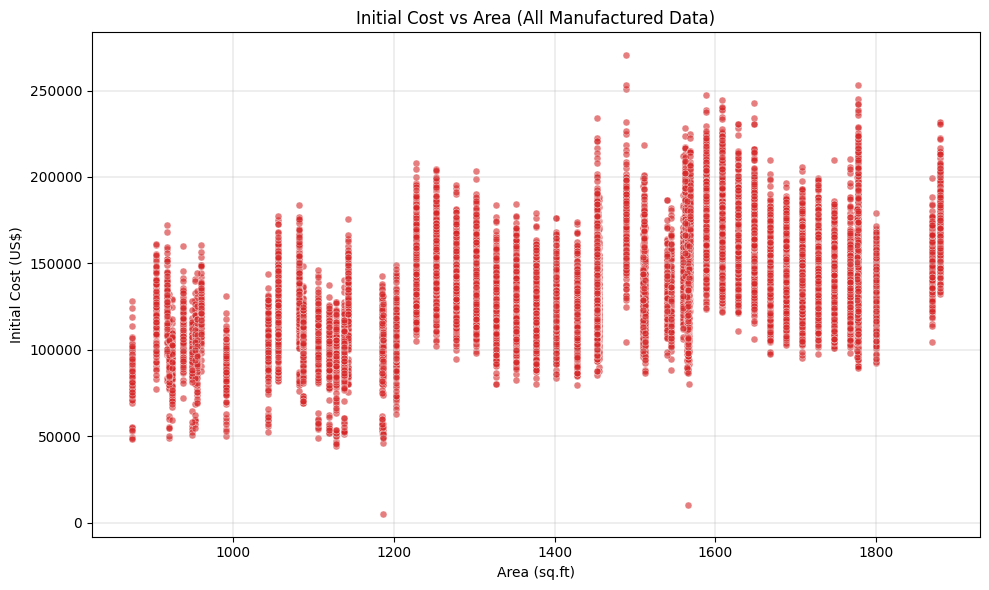

Saved to: E:\PhD Related Documents\Codes\ml_projects\lcc\New Figures


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Load dataset
df = pd.read_csv("only_modular.csv")
df.columns = df.columns.str.strip()

# Optional: ensure numeric columns are clean
df["Area"] = pd.to_numeric(df["Area"], errors="coerce")
df["Initial Cost"] = pd.to_numeric(df["Initial Cost"], errors="coerce")
df = df.dropna(subset=["Area", "Initial Cost"])

# Plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Area",
    y="Initial Cost",
    color="#d62728",   # strong red (Manufactured)
    alpha=0.6,
    s=25
)

plt.title("Initial Cost vs Area (All Manufactured Data)")
plt.xlabel("Area (sq.ft)")
plt.ylabel("Initial Cost (US$)")
plt.grid(True, linewidth=0.3)
plt.tight_layout()

# ---- Save to New Figures folder ----
base_dir = Path(r"E:\PhD Related Documents\Codes\ml_projects\lcc")
out_dir = base_dir / "New Figures"
out_dir.mkdir(exist_ok=True)

plt.savefig(out_dir / "final_dataset_manufactured.png", dpi=600, bbox_inches="tight")
plt.savefig(out_dir / "final_dataset_manufactured.pdf", bbox_inches="tight")

plt.show()

print("Saved to:", out_dir)


***Correlation Matrix***

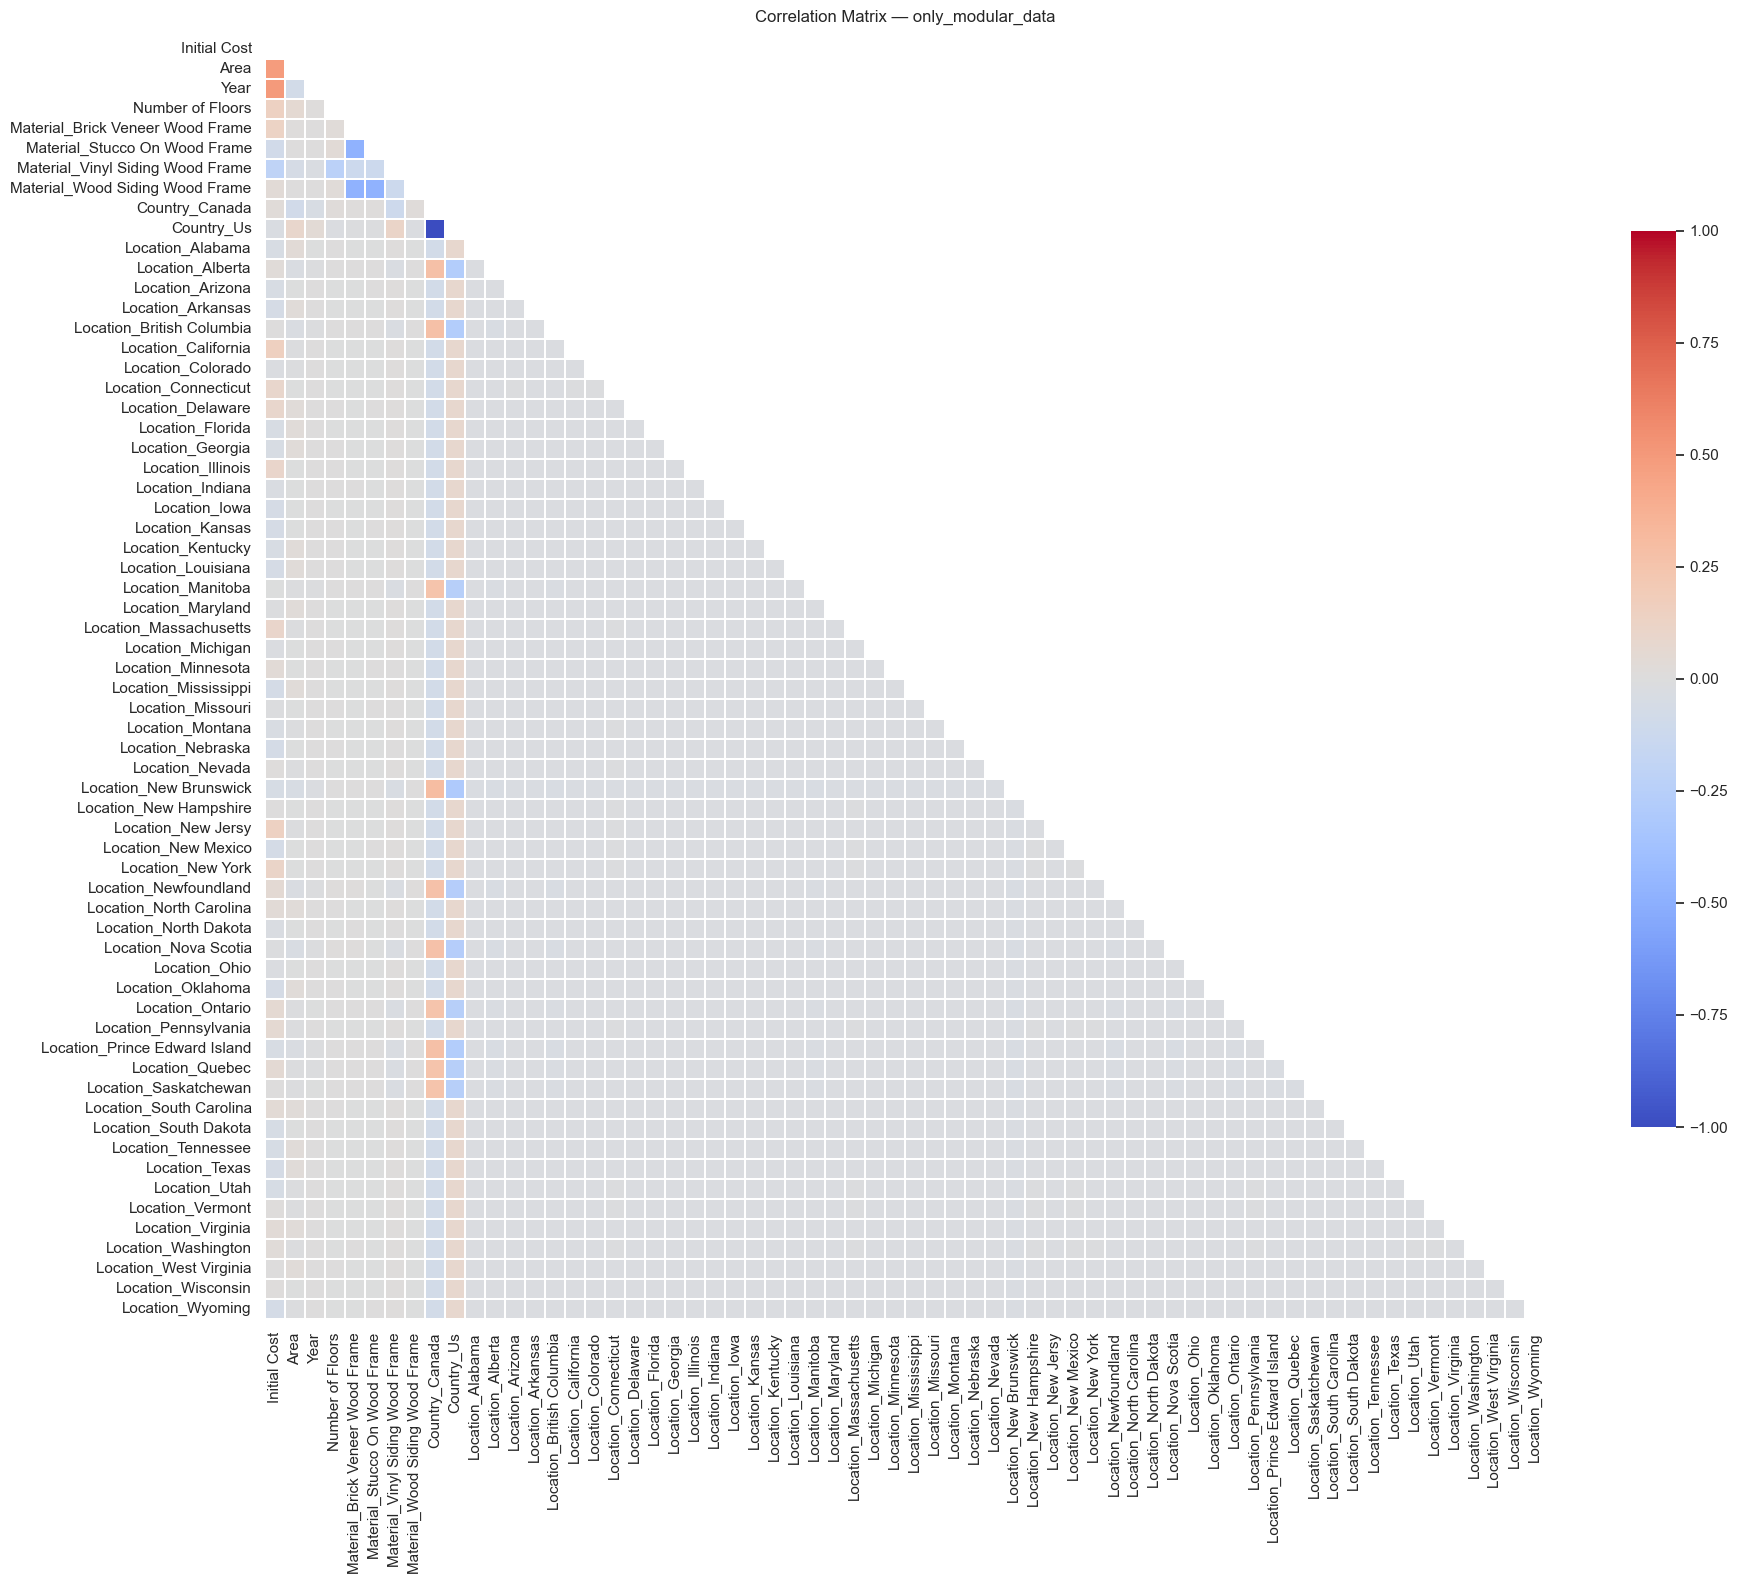


Data types used:
 Initial Cost         int64
Area                 int64
Year                 int64
Number of Floors     int64
Material            object
Country             object
Location            object
dtype: object

Top correlations with Initial Cost (abs, top 10):
Year                                0.497725
Area                                0.489116
Material_Vinyl Siding Wood Frame    0.207726
Location_California                 0.153083
Location_New Jersy                  0.141978
Number of Floors                    0.141156
Material_Brick Veneer Wood Frame    0.130763
Location_New York                   0.113833
Location_Massachusetts              0.100133
Location_Illinois                   0.099013
Name: Initial Cost, dtype: float64


In [4]:
# correlation_matrix_first_collected_data.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# -----------------------------
# 0) Config
# -----------------------------
CSV_PATH = "only_modular.csv"   # change if needed

NUM_COLS   = ["Initial Cost", "Area", "Year", "Number of Floors"]
CAT_COLS   = ["Material", "Country", "Location"]

# -----------------------------
# 1) Load & clean
# -----------------------------
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()


# trim string columns if present
for c in CAT_COLS:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

# numeric coercion (remove $, commas, spaces, etc.)
def to_num(s):
    s = pd.Series(s).astype(str)
    s = s.str.replace(r"[^0-9.\-eE]", "", regex=True)  # keep digits, ., -, scientific notation
    return pd.to_numeric(s, errors="coerce")

for c in NUM_COLS:
    if c in df.columns:
        df[c] = to_num(df[c])

# keep rows that have at least Area & Initial Cost for sanity
need = [c for c in ["Area", "Initial Cost"] if c in df.columns]
if need:
    df = df.dropna(subset=need).reset_index(drop=True)

# -----------------------------
# 2) Build the matrix data
# -----------------------------
# keep only columns that exist
use_num = [c for c in NUM_COLS if c in df.columns]
use_cat = [c for c in CAT_COLS if c in df.columns]

if not use_num:
    raise ValueError("No numeric columns found among: " + ", ".join(NUM_COLS))

# One-hot encode categoricals (don’t drop first so you see full relationships)
df_enc = pd.get_dummies(
    df[use_num + use_cat],
    columns=use_cat,
    drop_first=False,
    dtype=float
)

# Optional: if you have *many* categories, the matrix can get huge.
# You can uncomment the next line to drop near-constant columns:
# df_enc = df_enc.loc[:, df_enc.nunique() > 1]

corr = df_enc.corr()

# -----------------------------
# 3) Plot — Seaborn heatmap (upper triangle)
# -----------------------------
sns.set_theme(context="notebook", style="white")

# mask upper triangle for readability
mask = np.triu(np.ones_like(corr, dtype=bool))

# If the matrix is very large, turn off annotations
annot = corr.shape[0] <= 25

plt.figure(figsize=(min(1.0*corr.shape[0], 20), min(0.8*corr.shape[0], 16)))
ax = sns.heatmap(
    corr, mask=mask, vmin=-1, vmax=1, center=0,
    cmap="coolwarm", square=True, linewidths=0.2,
    cbar_kws={"shrink": 0.7},
    annot=annot, fmt=".2f" if annot else ""
)
plt.title("Correlation Matrix — only_modular_data", pad=12)
plt.tight_layout()

# === Save the figure at 300 dpi ===
plt.savefig("correlation_matrix_only_modular_data.png", dpi=300, bbox_inches='tight')

plt.show()

# -----------------------------
# 4) (Optional) print quick summaries
# -----------------------------
print("\nData types used:\n", df[use_num + use_cat].dtypes)
print("\nTop correlations with Initial Cost (abs, top 10):")
if "Initial Cost" in corr.columns:
    target_corr = corr["Initial Cost"].drop(labels=["Initial Cost"], errors="ignore").abs().sort_values(ascending=False)
    print(target_corr.head(10))


***Cost vs Location vs Material***

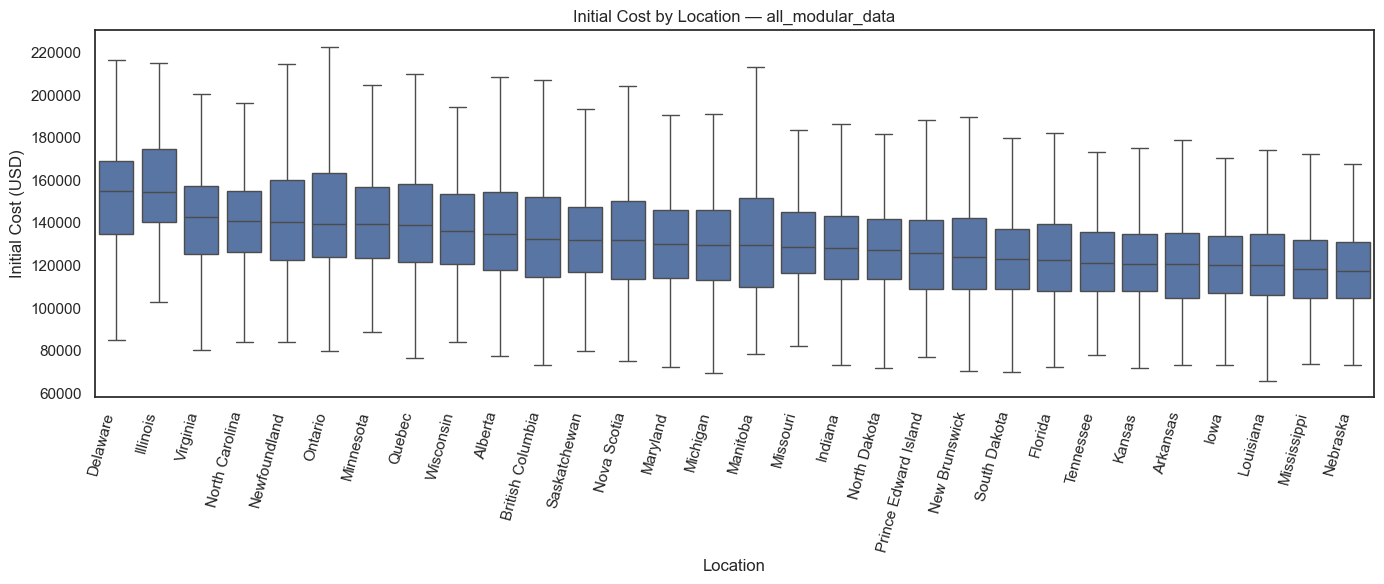

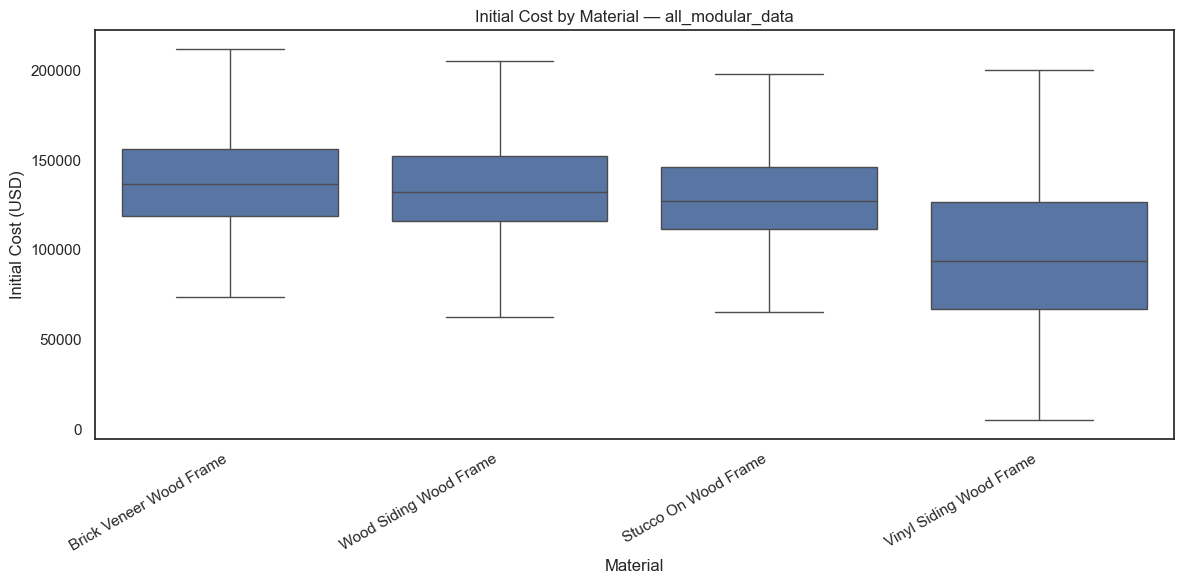

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------
# Load data (all modular)
# -------------------------
# If running in my environment: path = "/mnt/data/all_modular_data.csv"
path = "only_modular.csv"
df = pd.read_csv(path)
df.columns = df.columns.str.strip()

# Clean & normalize
for c in ["Area", "Year", "Number of Floors", "Initial Cost"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

for c in ["Location","Country","Material"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

df = df.dropna(subset=["Initial Cost"]).copy()

# ======================================================================
# Cost vs Location (single panel, since 'Type' is absent and all Modular)
# ======================================================================
top_n = 30  # show top N locations overall
top_locations = df["Location"].value_counts().nlargest(top_n).index.tolist()
df_loc = df[df["Location"].isin(top_locations)].copy()

# Order x by median cost (more readable)
order_loc = (
    df_loc.groupby("Location")["Initial Cost"]
          .median()
          .sort_values(ascending=False)
          .index.tolist()
)

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_loc, x="Location", y="Initial Cost",
    order=order_loc, showfliers=False
)
plt.title("Initial Cost by Location — all_modular_data")
plt.xlabel("Location")
plt.ylabel("Initial Cost (USD)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

# ======================================================================
# Cost vs Material (single panel)
# ======================================================================
top_n_mat = 10
top_materials = df["Material"].value_counts().nlargest(top_n_mat).index.tolist()
df_mat = df[df["Material"].isin(top_materials)].copy()

order_mat = (
    df_mat.groupby("Material")["Initial Cost"]
          .median()
          .sort_values(ascending=False)
          .index.tolist()
)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_mat, x="Material", y="Initial Cost",
    order=order_mat, showfliers=False
)
plt.title("Initial Cost by Material — all_modular_data")
plt.xlabel("Material")
plt.ylabel("Initial Cost (USD)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


***Cost vs Year vs Type***

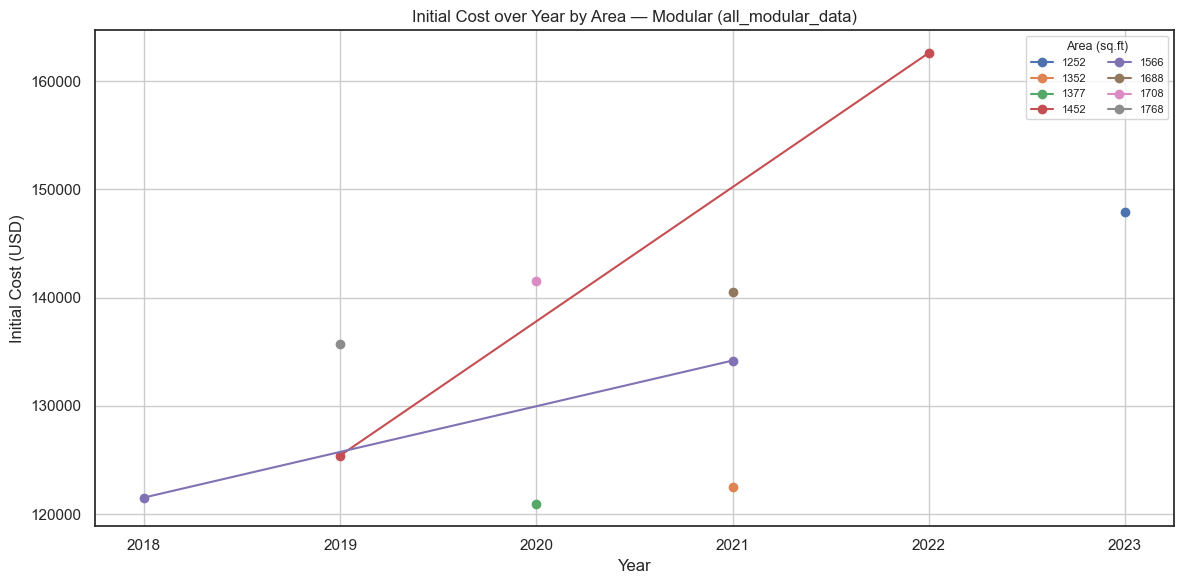

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Load current dataset
# -------------------------
# If running in my environment: path = "/mnt/data/all_modular_data.csv"
path = "only_modular.csv"
df = pd.read_csv(path)
df.columns = df.columns.str.strip()

# Ensure numeric dtypes
for c in ["Area", "Year", "Number of Floors", "Initial Cost"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Keep essentials
df = df.dropna(subset=["Area", "Year", "Initial Cost"]).copy()

# Aggregate mean Initial Cost by (Area, Year)
agg = (
    df.groupby(["Area", "Year"], as_index=False)["Initial Cost"]
      .mean()
      .sort_values(["Area", "Year"])
)

TOP_N = 8  # number of area lines to show
top_areas = (
    df["Area"].value_counts()
      .nlargest(TOP_N)
      .index.tolist()
)
agg_top = agg[agg["Area"].isin(top_areas)].copy()

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(12, 6))
for a in sorted(top_areas):
    sub = agg_top[agg_top["Area"] == a].sort_values("Year")
    if len(sub) == 0:
        continue
    plt.plot(sub["Year"], sub["Initial Cost"], marker="o", label=f"{int(a)}")

plt.title("Initial Cost over Year by Area — Modular (all_modular_data)")
plt.xlabel("Year")
plt.ylabel("Initial Cost (USD)")
plt.grid(True)
plt.legend(title="Area (sq.ft)", fontsize=8, title_fontsize=9, ncols=2)
plt.tight_layout()
plt.show()


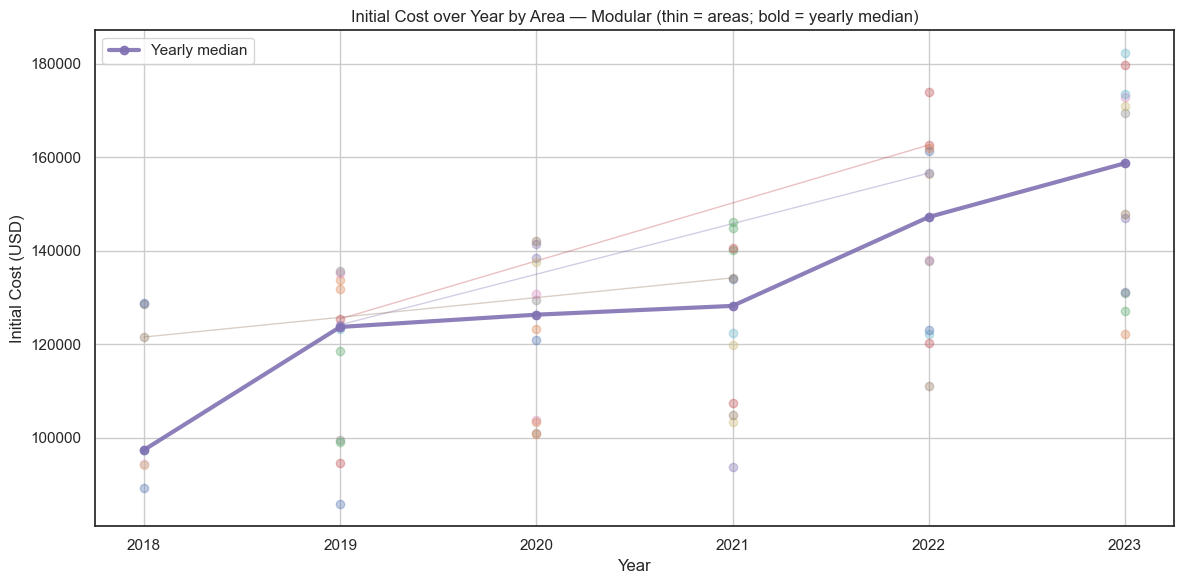

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Load current dataset
# -------------------------
# If running in my environment: path = "/mnt/data/all_modular_data.csv"
path = "only_modular.csv"
df = pd.read_csv(path)
df.columns = df.columns.str.strip()

# Clean numerics
for c in ["Area", "Year", "Number of Floors", "Initial Cost"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Keep essentials
df = df.dropna(subset=["Area", "Year", "Initial Cost"]).copy()

# --------------------------------------------
# Keep areas that have data in >= 1 years
# (so lines make sense across time)
# --------------------------------------------
areas_to_keep = (
    df.groupby("Area")["Year"].nunique()
      .loc[lambda s: s >= 1].index
)
dft = df[df["Area"].isin(areas_to_keep)].copy()

# Aggregate duplicates (same Area–Year) with mean
dft = (
    dft.groupby(["Area", "Year"], as_index=False)["Initial Cost"]
       .mean()
       .sort_values(["Area", "Year"])
)

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(12, 6))

# Thin transparent lines: each Area
for a, sub in dft.groupby("Area"):
    sub = sub.sort_values("Year")
    plt.plot(sub["Year"], sub["Initial Cost"], marker="o", linewidth=1, alpha=0.35)

# Bold median trend across areas per year
med = (
    dft.groupby("Year")["Initial Cost"].median()
       .reset_index()
       .sort_values("Year")
)
plt.plot(med["Year"], med["Initial Cost"], marker="o", linewidth=3, alpha=0.9, label="Yearly median")

plt.title("Initial Cost over Year by Area — Modular (thin = areas; bold = yearly median)")
plt.xlabel("Year")
plt.ylabel("Initial Cost (USD)")
plt.grid(True)
plt.legend(loc="best")

# Force ticks to match actual dataset years
years = sorted(dft["Year"].unique())
plt.xticks(years, years)

plt.tight_layout()
plt.show()


***Principal Component Analysis (PCA)***

Expanded feature count: 63
Full PCA components: 63
PCA(0.95) components: 43


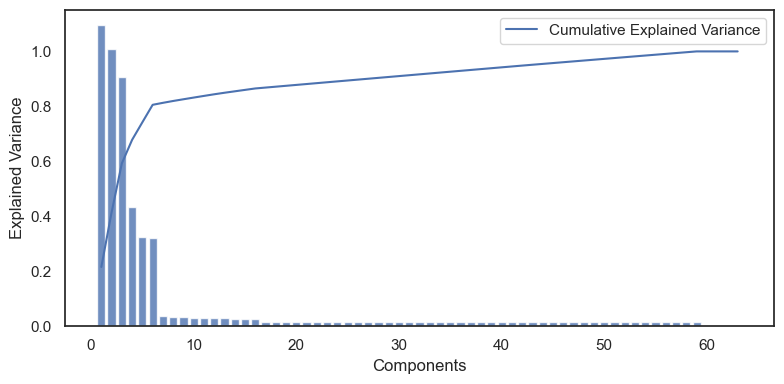

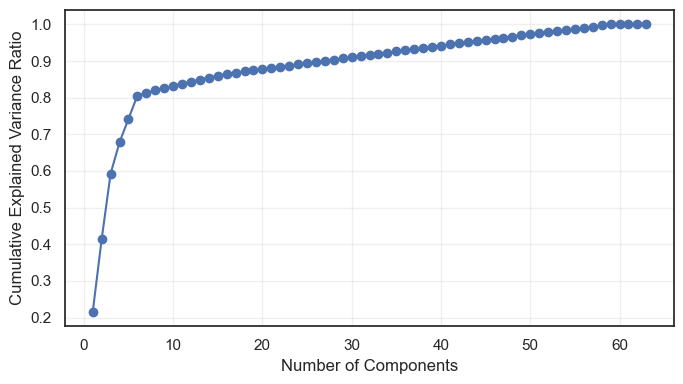


Top features for PC1:
Area                                0.728617
Number of Floors                    0.368615
Country_Us                          0.022787
Material_Stucco On Wood Frame       0.006101
Material_Brick Veneer Wood Frame    0.006080
Material_Wood Siding Wood Frame     0.005176
Location_Alabama                    0.003225
Location_Kentucky                   0.002642
Location_West Virginia              0.002576
Location_Arkansas                   0.002556
Name: PC1, dtype: float64


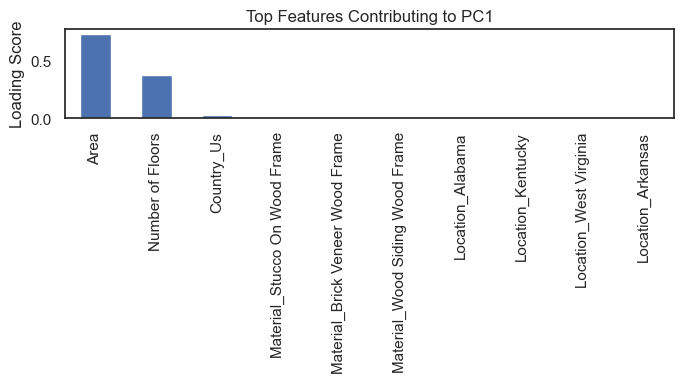


Top features for PC2:
Number of Floors                    0.823558
Year                                0.564970
Area                                0.028242
Material_Stucco On Wood Frame       0.013925
Material_Brick Veneer Wood Frame    0.010538
Material_Wood Siding Wood Frame     0.010493
Country_Us                          0.007489
Location_Oklahoma                   0.000786
Location_Georgia                    0.000521
Location_Delaware                   0.000511
Name: PC2, dtype: float64


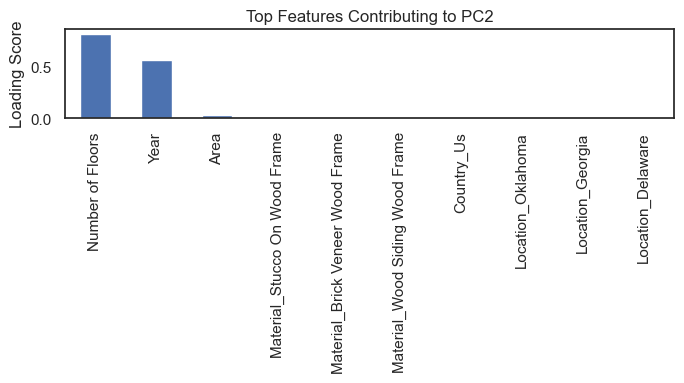

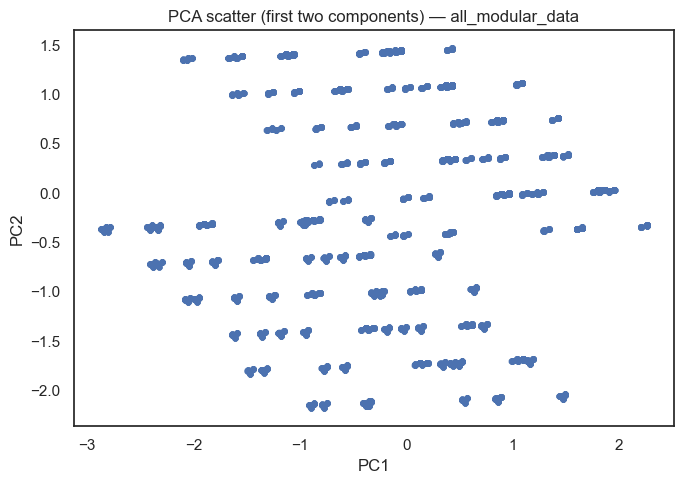

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA

# --------------------------------
# 1) Load & tidy (all_modular_data)
# --------------------------------
# If running in my environment: PATH = "/mnt/data/all_modular_data.csv"
PATH = "only_modular.csv"
df = pd.read_csv(PATH)
df.columns = df.columns.str.strip()

# keep columns if present
cols = ["Area","Year","Location","Country","Number of Floors","Material","Initial Cost"]
cols = [c for c in cols if c in df.columns]
df = df[cols].copy()

# numerics
for c in ["Area","Year","Number of Floors","Initial Cost"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# strings
for c in ["Location","Country","Material"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

# essential predictors (no 'Type' in this dataset)
essential = [c for c in ["Area","Year","Number of Floors","Location","Country","Material"] if c in df.columns]
df = df.dropna(subset=essential).reset_index(drop=True)

# --------------------------------
# 2) Build X (features only)
# --------------------------------
cat_features = [c for c in ["Location","Country","Material"] if c in df.columns]
num_features = [c for c in ["Area","Year","Number of Floors"] if c in df.columns]
X_df = df[cat_features + num_features].copy()

# --------------------------------
# 3) Preprocess (OneHot + Scale) and PCA
# --------------------------------
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)   # sklearn >= 1.2
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)          # older sklearn

ct = ColumnTransformer(
    transformers=[
        ("cat", ohe, cat_features),
        ("num", StandardScaler(), num_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

X_mat = ct.fit_transform(X_df)
feature_names = ct.get_feature_names_out()

# PCA (full) + PCA(95%)
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_mat)

pca95 = PCA(0.95)
X_pca95 = pca95.fit_transform(X_mat)
print("Expanded feature count:", len(feature_names))
print("Full PCA components:", pca_full.n_components_)
print("PCA(0.95) components:", pca95.n_components_)

# --------------------------------
# 4) Explained variance plots
# --------------------------------
plt.figure(figsize=(8,4))
plt.bar(range(1, len(pca_full.explained_variance_) + 1),
        pca_full.explained_variance_, alpha=0.8)
plt.plot(range(1, len(pca_full.explained_variance_) + 1),
         np.cumsum(pca_full.explained_variance_ratio_),
         label="Cumulative Explained Variance")
plt.xlabel("Components"); plt.ylabel("Explained Variance")
plt.legend(loc="upper right")
plt.tight_layout(); 
# === Save the figure at 300 dpi ===
plt.savefig("explained_variance.png", dpi=300, bbox_inches='tight')

plt.show()

plt.figure(figsize=(7,4))
plt.plot(np.arange(1, len(pca_full.explained_variance_ratio_) + 1),
         np.cumsum(pca_full.explained_variance_ratio_), marker="o")
plt.xlabel("Number of Components"); plt.ylabel("Cumulative Explained Variance Ratio")
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# --------------------------------
# 5) Loadings (feature contributions)
# --------------------------------
loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f"PC{i+1}" for i in range(pca_full.components_.shape[0])],
    index=feature_names
)

print("\nTop features for PC1:")
print(loadings["PC1"].sort_values(ascending=False).head(10))

plt.figure(figsize=(7,4))
loadings["PC1"].sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top Features Contributing to PC1"); plt.ylabel("Loading Score")
plt.tight_layout(); plt.show()

print("\nTop features for PC2:")
print(loadings["PC2"].sort_values(ascending=False).head(10))

plt.figure(figsize=(7,4))
loadings["PC2"].sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top Features Contributing to PC2"); plt.ylabel("Loading Score")
plt.tight_layout(); plt.show()

# --------------------------------
# 6) 2D scatter of first two PCs
# (no 'Type' column; simple scatter or color by a category if desired)
# --------------------------------
pc_df = pd.DataFrame(X_pca_full[:, :2], columns=["PC1","PC2"])

# SIMPLE: uncolored scatter
plt.figure(figsize=(7,5))
plt.scatter(pc_df["PC1"], pc_df["PC2"], s=12, alpha=0.6)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("PCA scatter (first two components) — all_modular_data")
plt.tight_layout(); plt.show()

# OPTIONAL: color by a categorical (e.g., top 8 Materials)
# Uncomment to use
# color_col = "Material"   # or "Location" / "Country"
# if color_col in df.columns:
#     top_vals = df[color_col].value_counts().nlargest(8).index
#     mask = df[color_col].isin(top_vals)
#     pc_df[color_col] = df[color_col].where(mask, "Other").values
#     plt.figure(figsize=(7,5))
#     for v, g in pc_df.groupby(color_col):
#         plt.scatter(g["PC1"], g["PC2"], s=12, alpha=0.6, label=v)
#     plt.legend(title=color_col, fontsize=8)
#     plt.xlabel("PC1"); plt.ylabel("PC2")
#     plt.title(f"PCA scatter by {color_col} — all_modular_data")
#     plt.tight_layout(); plt.show()


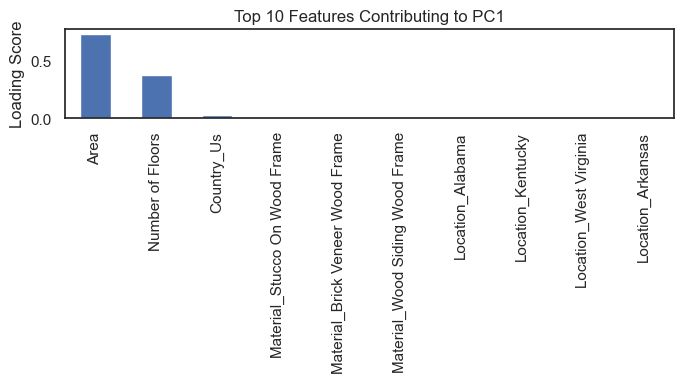

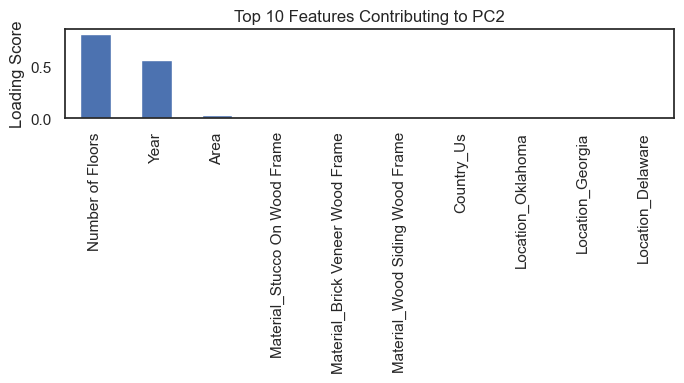

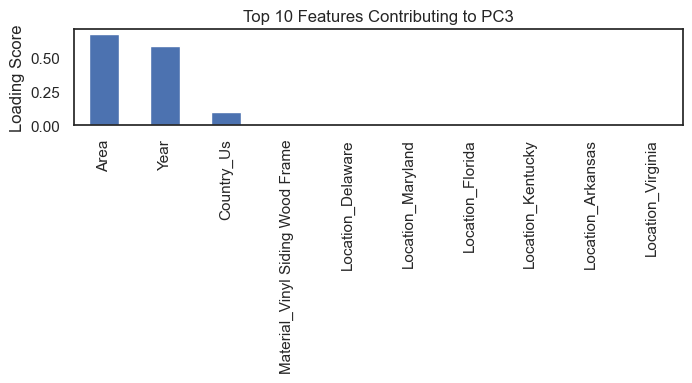

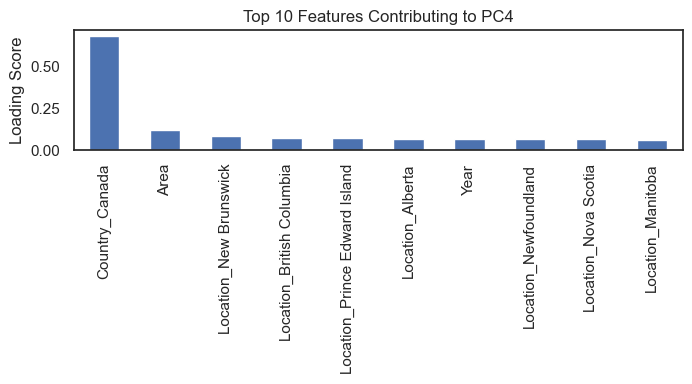

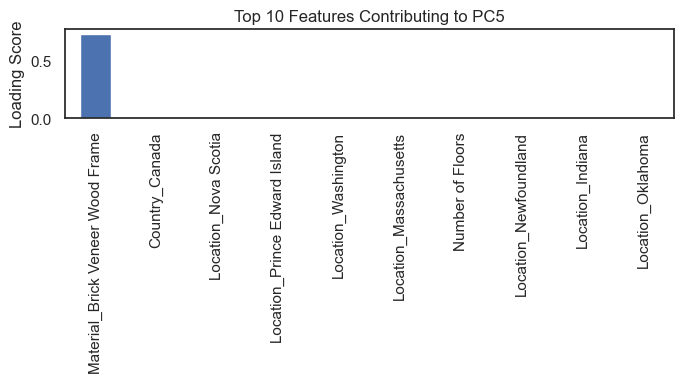

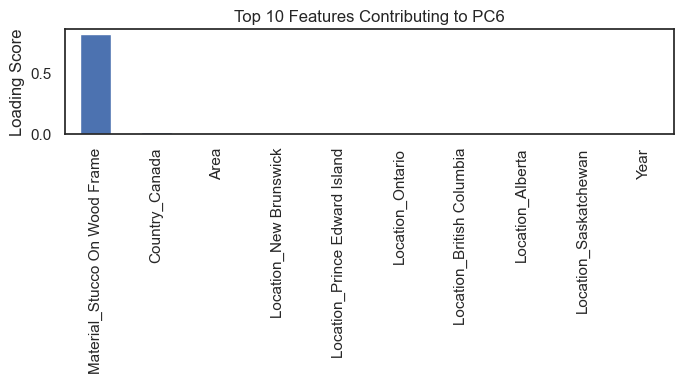

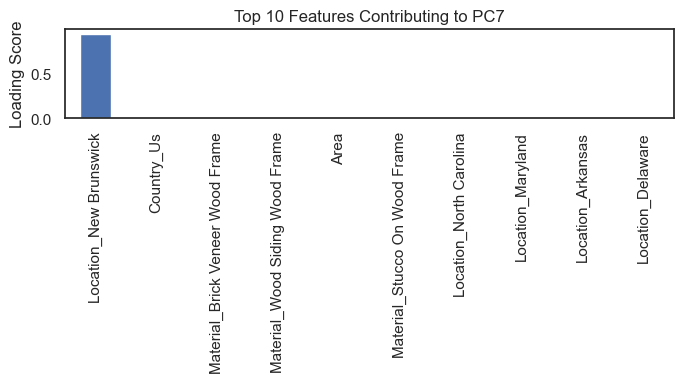

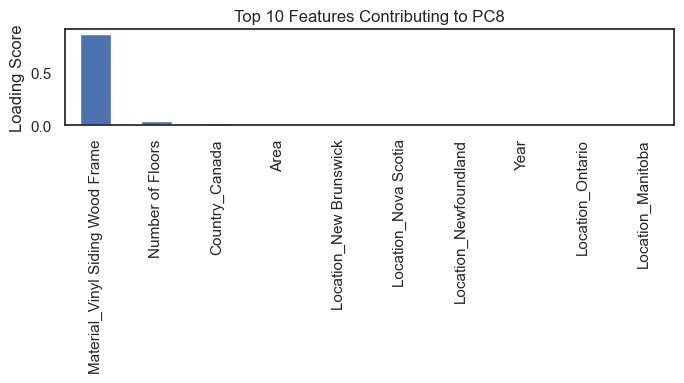

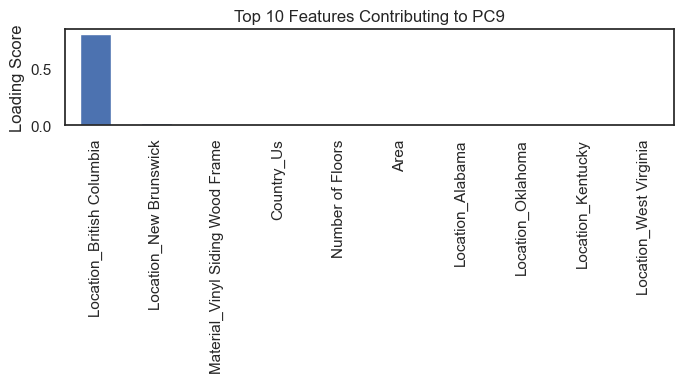

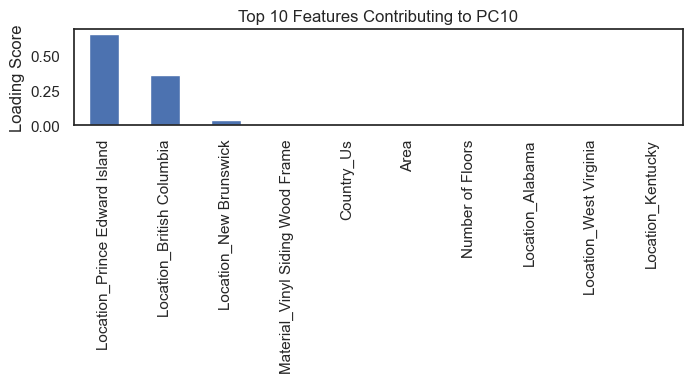

In [9]:
# -----------------------------
# Plot top features up to PC10
# -----------------------------
top_k_pcs = min(10, loadings.shape[1])  # up to 10 PCs or as many as available

for i in range(top_k_pcs):
    pc = f"PC{i+1}"
    top_feats = loadings[pc].sort_values(ascending=False).head(10)
    
    plt.figure(figsize=(7,4))
    top_feats.plot(kind="bar")
    plt.title(f"Top 10 Features Contributing to {pc}")
    plt.ylabel("Loading Score")
    plt.tight_layout()
    plt.show()


***Training Machine Learning Model***

In [10]:
import pandas as pd, numpy as np, json, joblib
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error, mean_squared_error

# ----------------------------
# Paths
# ----------------------------
DATA_PATH    = "only_modular.csv"   # use "/mnt/data/all_modular_data.csv" in my env
METRICS_PATH = "ensemble_cv_summary_allmodular.csv"
MODEL_PATH   = "best_auto_model_allmodular.joblib"
SPEC_PATH    = "auto_model_spec_allmodular.json"

# ----------------------------
# Load + tidy (tab-delimited)
# ----------------------------
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

# independent vars in this dataset
needed_X = ["Area","Year","Location","Country","Number of Floors","Material"]
target   = "Initial Cost"

have_X = [c for c in needed_X if c in df.columns]
if target not in df.columns:
    raise ValueError(f'"{target}" column not found in {DATA_PATH}')

# clean categoricals
for c in ["Location","Country","Material"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

# clean numerics
for c in ["Area","Year","Number of Floors","Initial Cost"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# drop rows with missing core fields
df = df.dropna(subset=have_X + [target]).reset_index(drop=True)

X = df[have_X].copy()
y = df[target].values

# ----------------------------
# Preprocessors
# ----------------------------
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)   # sklearn >=1.2
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)          # older sklearn

cat_cols = [c for c in ["Location","Country","Material"] if c in X.columns]
num_cols = [c for c in ["Area","Year","Number of Floors"] if c in X.columns]

ohe_lr_rf = make_ohe()
ohe_svr   = make_ohe()

pre_lr_rf = ColumnTransformer(
    [("cat", ohe_lr_rf, cat_cols),
     ("num", "passthrough", num_cols)],
    remainder="drop", verbose_feature_names_out=False
)

pre_svr = ColumnTransformer(
    [("cat", ohe_svr, cat_cols),
     ("num", MinMaxScaler(), num_cols)],
    remainder="drop", verbose_feature_names_out=False
)

# ----------------------------
# Models
# ----------------------------
models = {
    "Linear Regression": Pipeline([
        ("pre", pre_lr_rf),
        ("model", LinearRegression())
    ]),
    "SVR (Linear, C=1000)": Pipeline([
        ("pre", pre_svr),
        ("model", SVR(kernel="linear", C=1000, epsilon=0.1))
    ]),
    "Random Forest": Pipeline([
        ("pre", pre_lr_rf),
        ("model", RandomForestRegressor(
            n_estimators=400, random_state=42, n_jobs=-1
        ))
    ]),
}

# ----------------------------
# Cross-validation & scoring
# ----------------------------
n_splits = max(2, min(5, len(X)))  # ensure <= n_samples and >= 2
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

scorers = {
    "r2":   make_scorer(r2_score),
    "mae":  make_scorer(mean_absolute_error, greater_is_better=False),
    "rmse": make_scorer(lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)),
                        greater_is_better=False),
}

rows = []
for name, pipe in models.items():
    cv = cross_validate(pipe, X, y, cv=kf, scoring=scorers, n_jobs=-1)
    rows.append({
        "Model": name,
        "R2_mean":   float(np.mean(cv["test_r2"])),
        "R2_std":    float(np.std(cv["test_r2"])),
        "MAE_mean":  float(-np.mean(cv["test_mae"])),
        "MAE_std":   float(np.std(-cv["test_mae"])),
        "RMSE_mean": float(-np.mean(cv["test_rmse"])),
        "RMSE_std":  float(np.std(-cv["test_rmse"])),
    })

cv_df = pd.DataFrame(rows).sort_values("RMSE_mean").reset_index(drop=True)
cv_df.to_csv(METRICS_PATH, index=False)

# ----------------------------
# Choose & save best model
# ----------------------------
best_name = cv_df.iloc[0]["Model"]
best_pipe = models[best_name].fit(X, y)
joblib.dump(best_pipe, MODEL_PATH)

with open(SPEC_PATH, "w") as f:
    json.dump({
        "chosen_model": best_name,
        "metrics_table": METRICS_PATH,
        "model_path": MODEL_PATH,
        "features_used": have_X,
        "target": target,
        "cv_folds": n_splits
    }, f, indent=2)

# ----------------------------
# Print leaderboard
# ----------------------------
print("\nCross-validated leaderboard (sorted by RMSE):")
print(cv_df.round({
    "R2_mean": 4, "R2_std": 4,
    "MAE_mean": 2, "MAE_std": 2,
    "RMSE_mean": 2, "RMSE_std": 2
}))
print(f"\nChosen: {best_name}")
print("Saved metrics ->", METRICS_PATH)
print("Saved model   ->", MODEL_PATH)
print("Spec JSON     ->", SPEC_PATH)



Cross-validated leaderboard (sorted by RMSE):
                  Model  R2_mean  R2_std  MAE_mean  MAE_std  RMSE_mean  \
0         Random Forest   0.7795  0.0072  10331.35   142.12   13338.86   
1     Linear Regression   0.7689  0.0081  10635.57    98.42   13654.66   
2  SVR (Linear, C=1000)   0.7652  0.0077  10637.93    85.61   13764.48   

   RMSE_std  
0    135.09  
1    117.30  
2     98.73  

Chosen: Random Forest
Saved metrics -> ensemble_cv_summary_allmodular.csv
Saved model   -> best_auto_model_allmodular.joblib
Spec JSON     -> auto_model_spec_allmodular.json


***Predicted vs Actual Cost Graph***

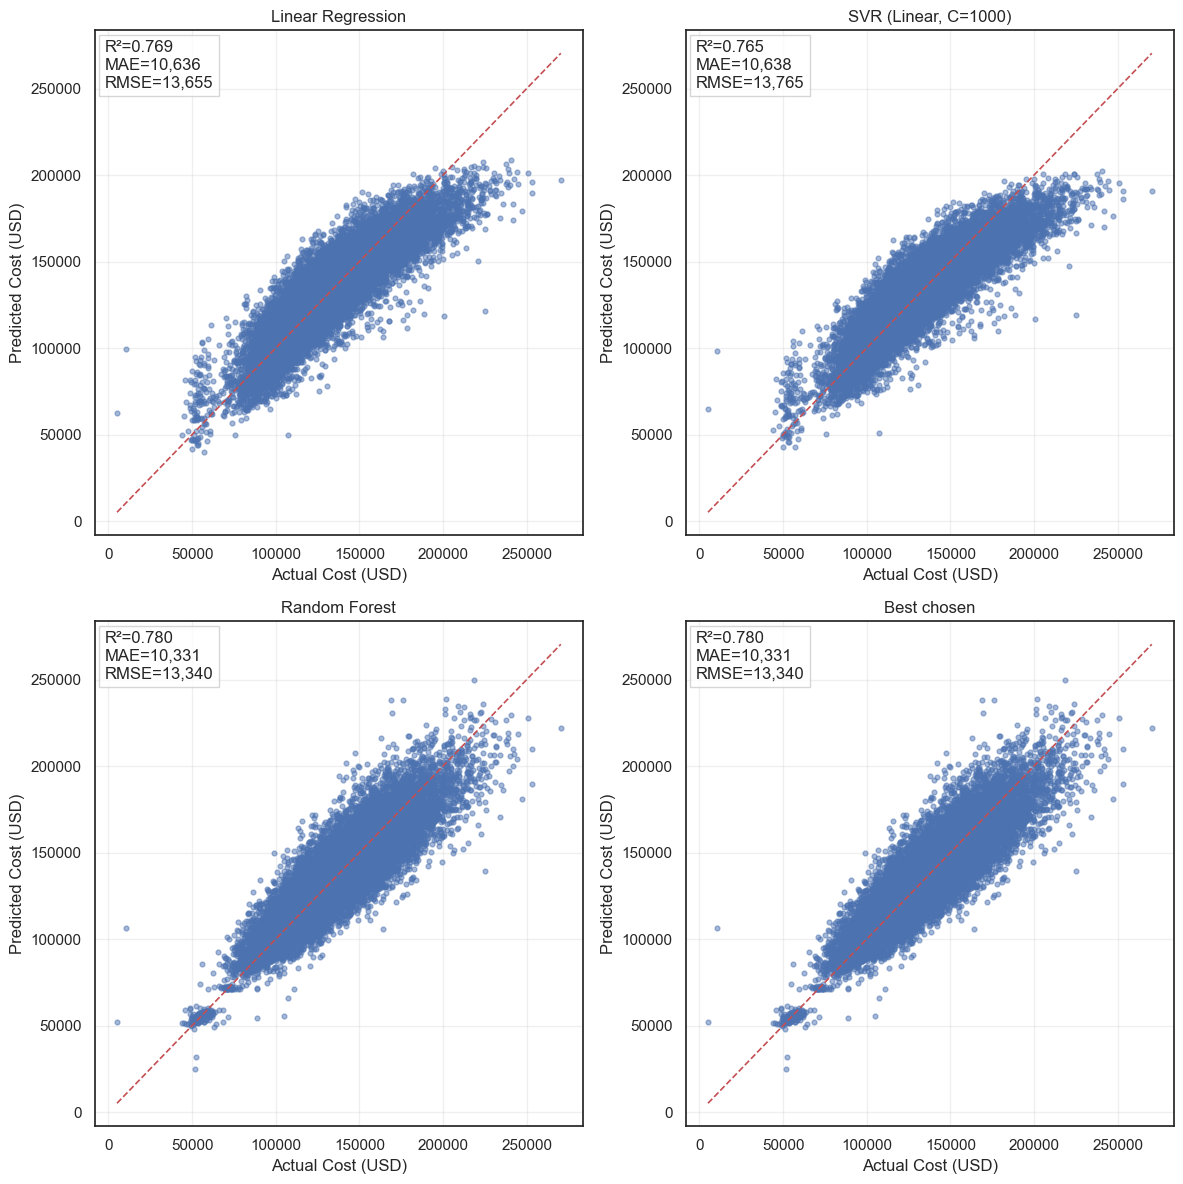

In [11]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict

# ----------------------------
# Plot Actual vs Predicted (OOF) for all models + chosen best
# ----------------------------
models_to_plot = models.copy()
models_to_plot["Best chosen"] = best_pipe   # add the trained best model

n_models = len(models_to_plot)
rows = int(np.ceil(n_models / 2))
cols = 2 if n_models > 1 else 1

fig, axes = plt.subplots(rows, cols, figsize=(12, 6*rows))
axes = np.array(axes).ravel() if isinstance(axes, np.ndarray) else np.array([axes])

def metrics_text(y_true, y_pred):
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return f"R²={r2:0.3f}\nMAE={mae:,.0f}\nRMSE={rmse:,.0f}"

for ax, (name, pipe) in zip(axes, models_to_plot.items()):
    y_oof = cross_val_predict(pipe, X, y, cv=kf, n_jobs=-1)
    ax.scatter(y, y_oof, s=12, alpha=0.5)
    lo, hi = float(np.min(y)), float(np.max(y))
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.2, label="Perfect prediction")
    ax.set_title(name)
    ax.set_xlabel("Actual Cost (USD)")
    ax.set_ylabel("Predicted Cost (USD)")
    ax.text(0.02, 0.98, metrics_text(y, y_oof),
            transform=ax.transAxes, va="top", ha="left",
            bbox=dict(facecolor="white", alpha=0.8, edgecolor="0.8"))
    ax.grid(True, alpha=0.3)

# hide any unused subplots
for ax in axes[n_models:]:
    ax.axis("off")

plt.tight_layout()
# === Save the figure at 300 dpi ===
plt.savefig("actual_vs_predicted_performance.png", dpi=300, bbox_inches='tight')
plt.show()


***Overfitting Check (K-Fold)***


Linear Regression
  Fold 1: R2=0.7607, MAE=10,785, RMSE=13,790
  Fold 2: R2=0.7742, MAE=10,519, RMSE=13,532
  Fold 3: R2=0.7603, MAE=10,696, RMSE=13,789
  Fold 4: R2=0.7678, MAE=10,637, RMSE=13,638
  Fold 5: R2=0.7814, MAE=10,541, RMSE=13,524
  Avg   : R2=0.7689, MAE=10,636, RMSE=13,655


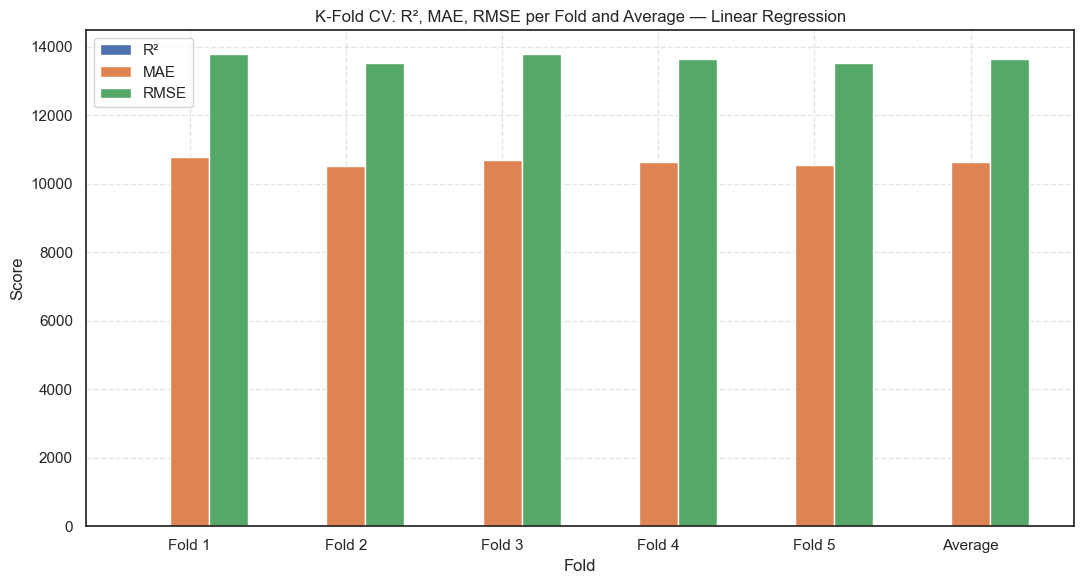

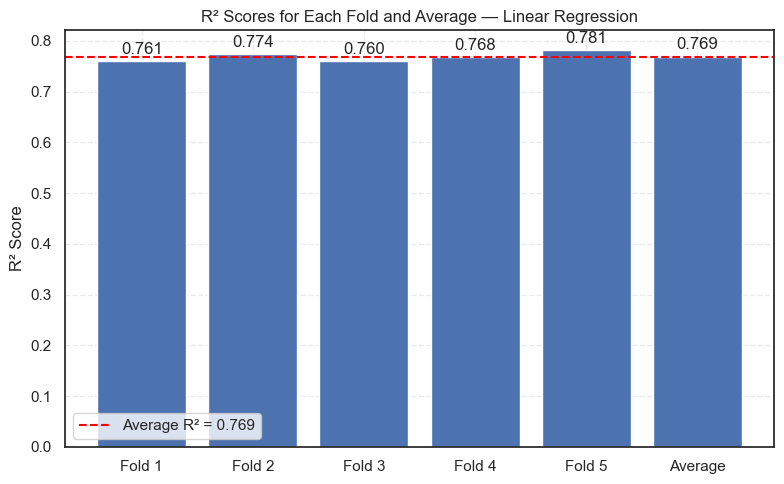


SVR (Linear, C=1000)
  Fold 1: R2=0.7573, MAE=10,770, RMSE=13,889
  Fold 2: R2=0.7685, MAE=10,570, RMSE=13,702
  Fold 3: R2=0.7575, MAE=10,679, RMSE=13,869
  Fold 4: R2=0.7647, MAE=10,646, RMSE=13,729
  Fold 5: R2=0.7779, MAE=10,525, RMSE=13,634
  Avg   : R2=0.7652, MAE=10,638, RMSE=13,764


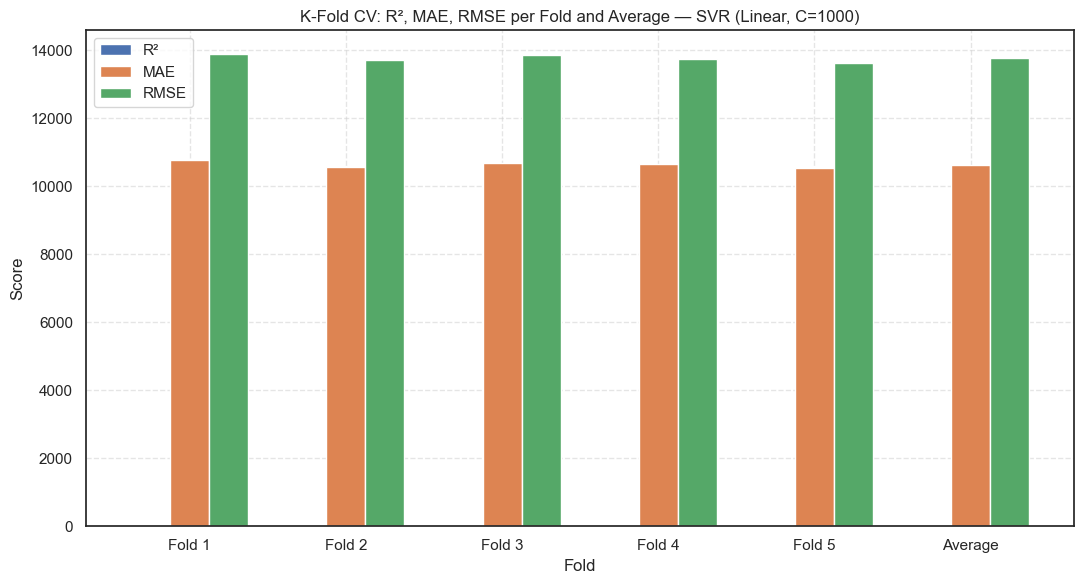

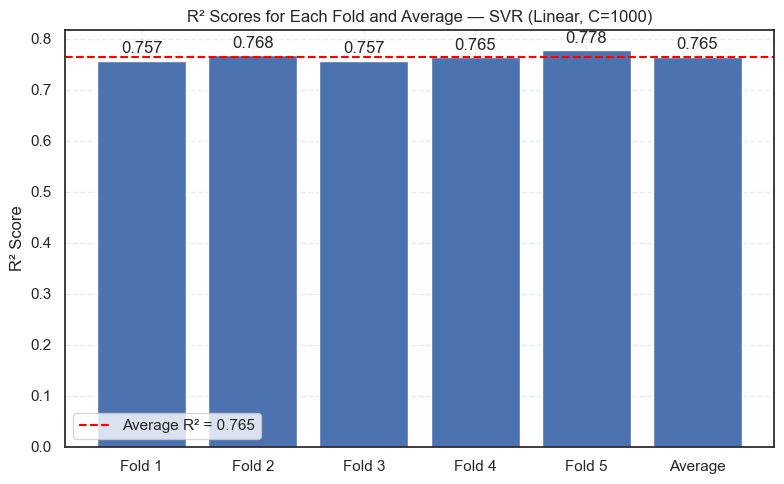


Random Forest
  Fold 1: R2=0.7717, MAE=10,517, RMSE=13,472
  Fold 2: R2=0.7784, MAE=10,456, RMSE=13,405
  Fold 3: R2=0.7816, MAE=10,139, RMSE=13,159
  Fold 4: R2=0.7736, MAE=10,330, RMSE=13,464
  Fold 5: R2=0.7920, MAE=10,214, RMSE=13,193
  Avg   : R2=0.7795, MAE=10,331, RMSE=13,339


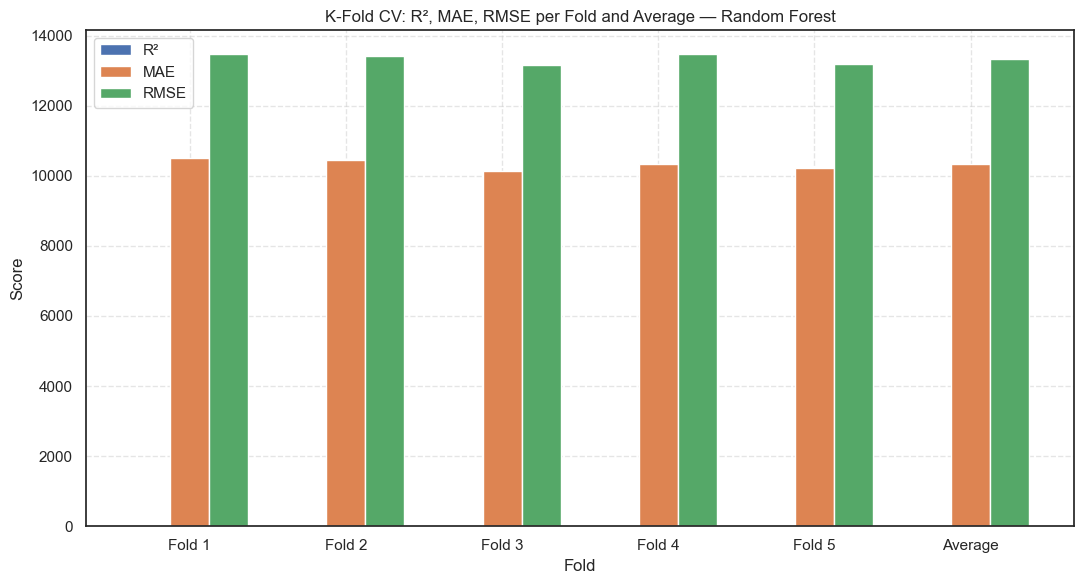

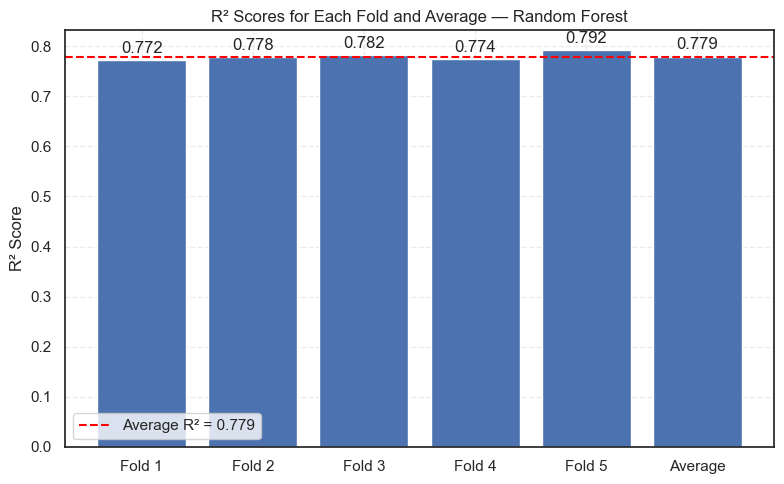


Best saved (auto)
  Fold 1: R2=0.7717, MAE=10,517, RMSE=13,472
  Fold 2: R2=0.7784, MAE=10,456, RMSE=13,405
  Fold 3: R2=0.7816, MAE=10,139, RMSE=13,159
  Fold 4: R2=0.7736, MAE=10,330, RMSE=13,464
  Fold 5: R2=0.7920, MAE=10,214, RMSE=13,193
  Avg   : R2=0.7795, MAE=10,331, RMSE=13,339


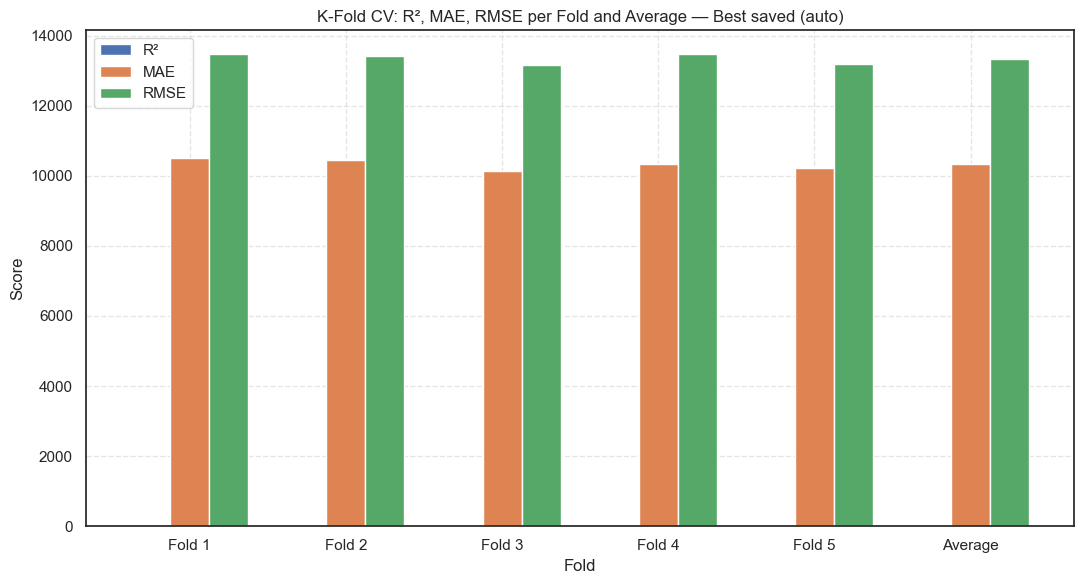

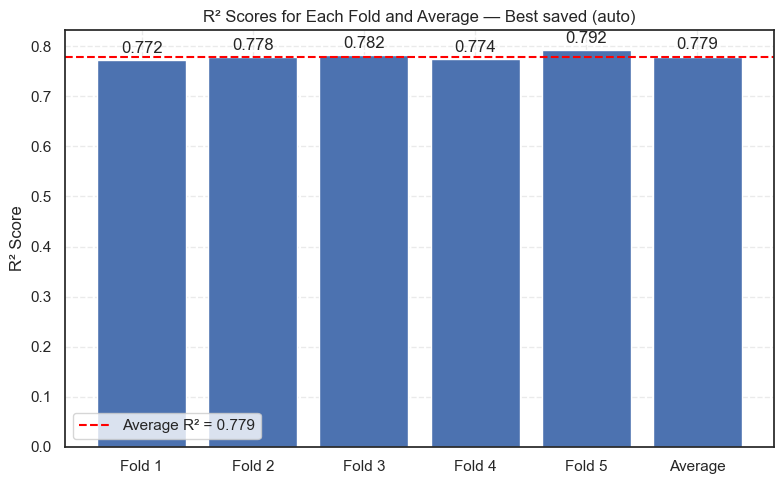

In [12]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, joblib
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ----------------------------
# Load & tidy data (tab-delimited)
# ----------------------------
DATA_PATH = "only_modular.csv"  # or "/mnt/data/all_modular_data.csv"
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

# features/target for this dataset
feat_cols = ["Area","Year","Location","Country","Number of Floors","Material"]
feat_cols = [c for c in feat_cols if c in df.columns]
target = "Initial Cost"

# clean strings & numerics
for c in ["Location","Country","Material"]:
    if c in df.columns: df[c] = df[c].astype(str).str.strip()
for c in ["Area","Year","Number of Floors","Initial Cost"]:
    if c in df.columns: df[c] = pd.to_numeric(df[c], errors="coerce")

# drop missing
df = df.dropna(subset=feat_cols + [target]).reset_index(drop=True)
X = df[feat_cols].copy()
y = df[target].astype(float).values

# ----------------------------
# Preprocessors (version-safe OHE)
# ----------------------------
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)  # sklearn >= 1.2
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)         # older sklearn

cat_cols = [c for c in ["Location","Country","Material"] if c in X.columns]
num_cols = [c for c in ["Area","Year","Number of Floors"] if c in X.columns]

pre_lr_rf = ColumnTransformer(
    [("cat", make_ohe(), cat_cols),
     ("num", "passthrough", num_cols)],
    remainder="drop", verbose_feature_names_out=False
)
pre_svr = ColumnTransformer(
    [("cat", make_ohe(), cat_cols),
     ("num", MinMaxScaler(), num_cols)],
    remainder="drop", verbose_feature_names_out=False
)

models = {
    "Linear Regression": Pipeline([("pre", pre_lr_rf), ("model", LinearRegression())]),
    "SVR (Linear, C=1000)": Pipeline([("pre", pre_svr), ("model", SVR(kernel="linear", C=1000, epsilon=0.1))]),
    "Random Forest": Pipeline([("pre", pre_lr_rf), ("model", RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1))]),
}

# Add your saved best pipeline (already includes its own preprocessor)
try:
    models["Best saved (auto)"] = joblib.load("best_auto_model_allmodular.joblib")
except Exception as e:
    print(f"[Info] Could not load best_auto_model_allmodular.joblib: {e}")

# ----------------------------
# K-fold evaluation helper
# ----------------------------
def eval_kfold(pipe, X, y, n_splits=5, seed=42):
    n_splits = max(2, min(n_splits, len(X)))  # safety for small data
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    r2_scores, mae_scores, rmse_scores = [], [], []
    for tr, te in kf.split(X):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y[tr], y[te]

        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_te)

        r2_scores.append(r2_score(y_te, y_pred))
        mae_scores.append(mean_absolute_error(y_te, y_pred))
        rmse_scores.append(np.sqrt(((y_te - y_pred) ** 2).mean()))

    return np.array(r2_scores), np.array(mae_scores), np.array(rmse_scores)

def plot_grouped_bars(name, r2, mae, rmse, save_prefix=None):
    r2_list  = list(r2)  + [np.mean(r2)]
    mae_list = list(mae) + [np.mean(mae)]
    rmse_list= list(rmse)+ [np.mean(rmse)]

    labels = [f"Fold {i+1}" for i in range(len(r2))] + ["Average"]
    x = np.arange(len(labels)); width = 0.25

    plt.figure(figsize=(11, 6))
    plt.bar(x - width, r2_list,  width, label="R²")
    plt.bar(x,          mae_list, width, label="MAE")
    plt.bar(x + width,  rmse_list,width, label="RMSE")
    plt.title(f"K-Fold CV: R², MAE, RMSE per Fold and Average — {name}")
    plt.xlabel("Fold"); plt.ylabel("Score")
    plt.xticks(x, labels, rotation=0)
    plt.legend(); plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    if save_prefix: plt.savefig(f"{save_prefix}_all_metrics.png", dpi=300)
    plt.show()

def plot_r2_only(name, r2, save_prefix=None):
    avg = np.mean(r2)
    labels = [f"Fold {i+1}" for i in range(len(r2))] + ["Average"]
    values = list(r2) + [avg]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(labels, values)
    plt.axhline(avg, color="red", linestyle="--", label=f"Average R² = {avg:.3f}")
    for b in bars:
        h = b.get_height()
        plt.annotate(f"{h:.3f}", (b.get_x()+b.get_width()/2, h), xytext=(0,3),
                     textcoords="offset points", ha="center", va="bottom")
    plt.title(f"R² Scores for Each Fold and Average — {name}")
    plt.ylabel("R² Score"); plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(); plt.tight_layout()
    if save_prefix: plt.savefig(f"{save_prefix}_r2_only.png", dpi=300)
    
    plt.show()

# ----------------------------
# Run & plot per model
# ----------------------------
for name, pipe in models.items():
    r2, mae, rmse = eval_kfold(pipe, X, y, n_splits=5, seed=42)
    print(f"\n{name}")
    for i,(r, m, s) in enumerate(zip(r2, mae, rmse), 1):
        print(f"  Fold {i}: R2={r:.4f}, MAE={m:,.0f}, RMSE={s:,.0f}")
    print(f"  Avg   : R2={np.mean(r2):.4f}, MAE={np.mean(mae):,.0f}, RMSE={np.mean(rmse):,.0f}")

    # plots (set save_prefix to save PNGs)
    save_prefix = f"kfold_{name.replace(' ','_').replace('(','').replace(')','')}"
    plot_grouped_bars(name, r2, mae, rmse, save_prefix=save_prefix)
    plot_r2_only(name, r2, save_prefix=save_prefix)


***Feature Importance Random Forest***


Top 20 Most Important Features:

                             Feature  Importance
0                               Area    0.395453
1                               Year    0.253338
2   Material_Vinyl Siding Wood Frame    0.035543
3                Location_California    0.026299
4                   Number of Floors    0.022984
5                 Location_New Jersy    0.021916
6                  Location_New York    0.015766
7                  Location_Illinois    0.014266
8   Material_Brick Veneer Wood Frame    0.014020
9      Material_Stucco On Wood Frame    0.013655
10            Location_Massachusetts    0.013362
11              Location_Connecticut    0.011738
12                 Location_Delaware    0.011699
13   Material_Wood Siding Wood Frame    0.009053
14                    Country_Canada    0.008022
15                        Country_Us    0.007996
16             Location_Pennsylvania    0.007351
17           Location_South Carolina    0.005442
18               Location_Washingto

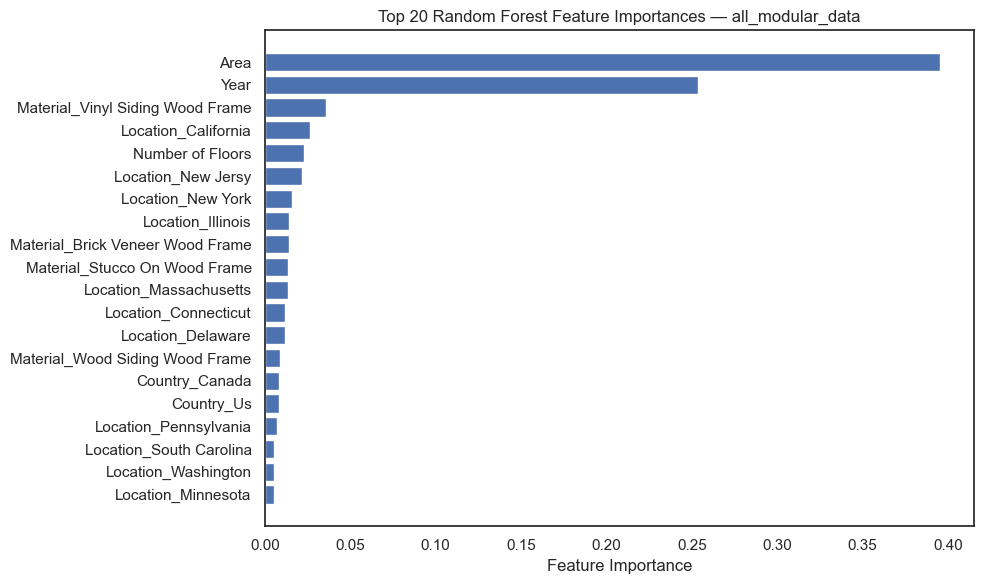

In [13]:
import pandas as pd, numpy as np, joblib, matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# ----------------------------
# Paths & settings
# ----------------------------
DATA_PATH  = "only_modular.csv"            # use "/mnt/data/all_modular_data.csv" if needed
MODEL_PATH = "best_auto_model_allmodular.joblib"
TOP_N      = 20

# ----------------------------
# Load & tidy data (tab-delimited, no 'Type')
# ----------------------------
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

feat_cols = ["Area","Year","Location","Country","Number of Floors","Material"]
feat_cols = [c for c in feat_cols if c in df.columns]
target = "Initial Cost"
if target not in df.columns:
    raise ValueError(f'"{target}" column not found in {DATA_PATH}')

# clean strings
for c in ["Location","Country","Material"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

# numerics
for c in ["Area","Year","Number of Floors","Initial Cost"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=feat_cols + [target]).reset_index(drop=True)
X = df[feat_cols].copy()
y = df[target].astype(float).values

# ----------------------------
# Helper: version-safe OneHotEncoder
# ----------------------------
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)  # sklearn >= 1.2
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)         # older sklearn

cat_cols = [c for c in ["Location","Country","Material"] if c in X.columns]
num_cols = [c for c in ["Area","Year","Number of Floors"] if c in X.columns]

pre_for_rf = ColumnTransformer(
    [("cat", make_ohe(), cat_cols),
     ("num", "passthrough", num_cols)],
    remainder="drop", verbose_feature_names_out=False
)

# ----------------------------
# Load best pipeline; if not RF, fit an RF pipeline now
# ----------------------------
pipe = joblib.load(MODEL_PATH)
# Try to detect the final estimator even if step name isn't "model"
step_names = list(pipe.named_steps.keys())
final_step_name = step_names[-1]
final_estimator = pipe.named_steps[final_step_name]

if isinstance(final_estimator, RandomForestRegressor):
    # Use saved RF pipeline
    rf_pipe = pipe
    rf_model = final_estimator
    # Try to fetch its preprocessor; if missing, fall back to our spec
    pre = rf_pipe.named_steps.get("pre", pre_for_rf)
else:
    # Refit a RandomForest with the same preprocessing on current data
    rf_pipe = Pipeline([
        ("pre", pre_for_rf),
        ("model", RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1))
    ])
    rf_pipe.fit(X, y)
    rf_model = rf_pipe.named_steps["model"]
    pre = rf_pipe.named_steps["pre"]

# ----------------------------
# Expanded feature names + importances
# ----------------------------
# Ensure we can get feature names (fit pre if needed)
try:
    feature_names = pre.get_feature_names_out()
except Exception:
    pre.fit(X)
    feature_names = pre.get_feature_names_out()

importances = rf_model.feature_importances_
if len(importances) != len(feature_names):
    raise RuntimeError(f"Mismatch: {len(importances)} importances vs {len(feature_names)} features")

importance_df = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
      .sort_values("Importance", ascending=False)
      .reset_index(drop=True)
)

# ----------------------------
# Print & plot top N
# ----------------------------
top_n = min(TOP_N, len(importance_df))
print(f"\nTop {top_n} Most Important Features:\n")
print(importance_df.head(top_n))

plt.figure(figsize=(10, 6))
plt.barh(importance_df.head(top_n)["Feature"], importance_df.head(top_n)["Importance"])
plt.xlabel("Feature Importance")
plt.title(f"Top {top_n} Random Forest Feature Importances — all_modular_data")
plt.gca().invert_yaxis()
plt.tight_layout()
# === Save the figure at 300 dpi ===
plt.savefig("feature_importance_rf.png", dpi=300, bbox_inches='tight')
plt.show()


***Coefficient for Regression***


[Fresh Linear Regression] intercept: -19638078.869935427

Top 20 LR coefficients by |value|:
                              Feature   Coefficient           Abs
0                Location_California  37173.428229  37173.428229
1                 Location_New Jersy  34309.992008  34309.992008
2                  Location_New York  27860.803582  27860.803582
3             Location_Massachusetts  24878.443706  24878.443706
4                  Location_Illinois  23253.677317  23253.677317
5               Location_Connecticut  22805.813136  22805.813136
6                  Location_Delaware  17453.797100  17453.797100
7   Material_Vinyl Siding Wood Frame -17013.533494  17013.533494
8               Location_Mississippi -16064.534840  16064.534840
9                 Location_Louisiana -15325.117209  15325.117209
10                    Location_Texas -15312.211500  15312.211500
11                 Location_Oklahoma -15288.553825  15288.553825
12                 Location_Arkansas -15258.203208  15258.20

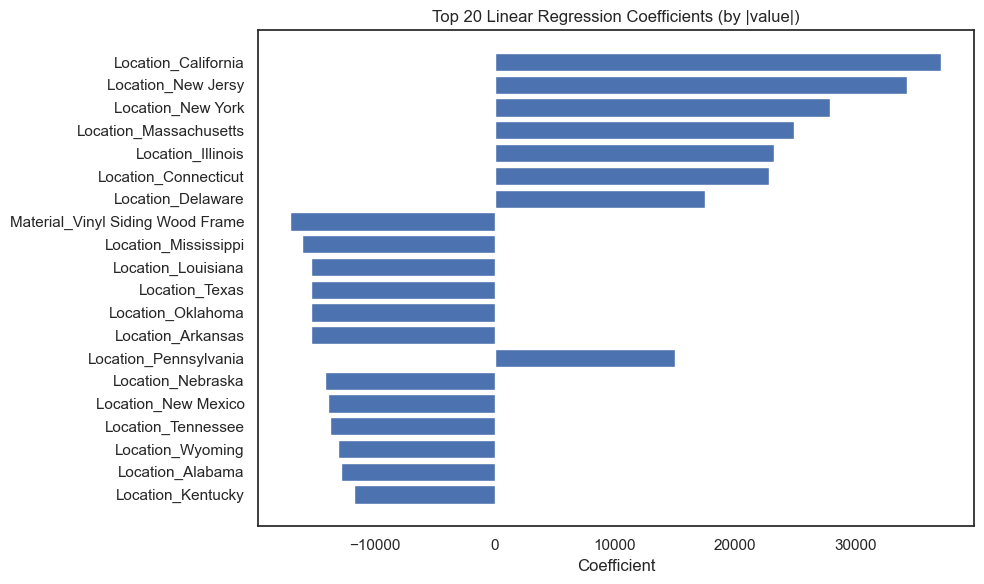

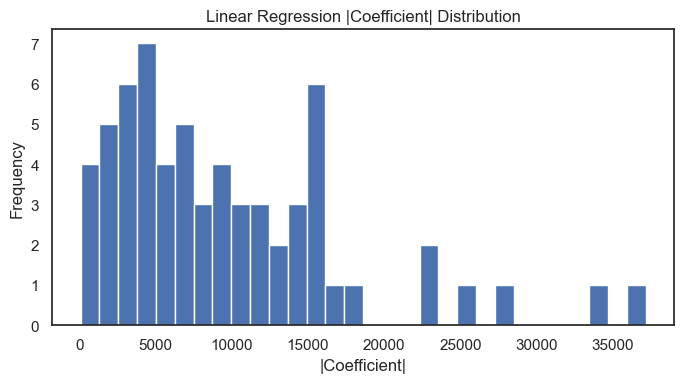


[Fresh SVR (linear)] intercept: 68278.00231157544

Top 20 SVR coefficients by |value|:
                              Feature   Coefficient           Abs
0                               Area  57894.158388  57894.158388
1                               Year  45880.696753  45880.696753
2                Location_California  33785.501551  33785.501551
3                 Location_New Jersy  32129.898387  32129.898387
4                  Location_New York  25390.593593  25390.593593
5                  Location_Illinois  22833.148383  22833.148383
6             Location_Massachusetts  21808.136699  21808.136699
7               Location_Connecticut  20075.344443  20075.344443
8   Material_Vinyl Siding Wood Frame -17614.058235  17614.058235
9                  Location_Delaware  16492.439874  16492.439874
10                 Location_Oklahoma -14770.420505  14770.420505
11              Location_Mississippi -14660.852295  14660.852295
12                 Location_Nebraska -14282.534330  14282.534330
1

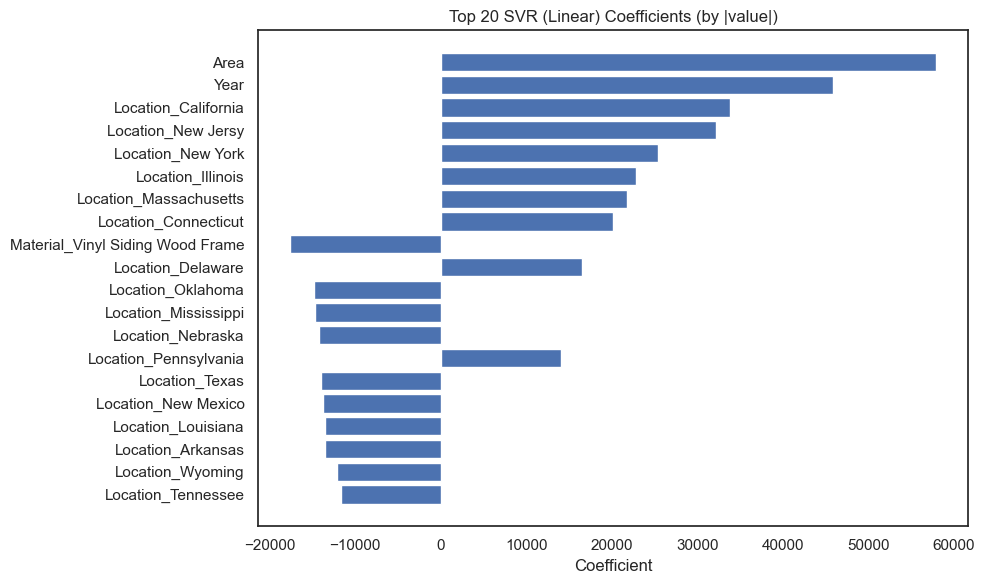

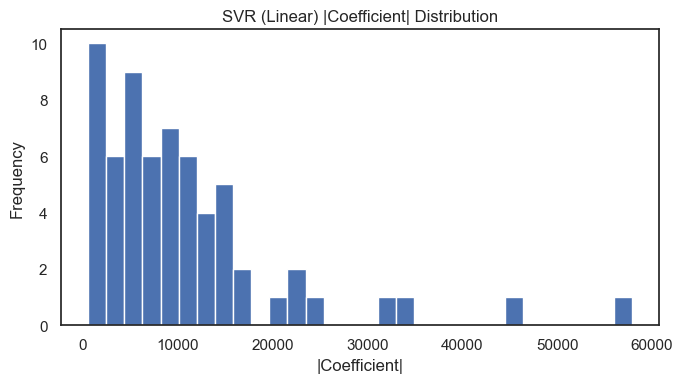


[Info] Best saved model is not LinearRegression or SVR(linear); coefficients not applicable.


In [14]:
import pandas as pd, numpy as np, joblib, matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

# ----------------------------
# Paths
# ----------------------------
DATA_PATH  = "only_modular.csv"          # or "/mnt/data/all_modular_data.csv"
MODEL_PATH = "best_auto_model_allmodular.joblib"
TOP_N      = 20

# ----------------------------
# Load & tidy (tab-delimited, no 'Type')
# ----------------------------
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

feat_cols = ["Area","Year","Location","Country","Number of Floors","Material"]
feat_cols = [c for c in feat_cols if c in df.columns]
target = "Initial Cost"
if target not in df.columns:
    raise ValueError(f'"{target}" column not found in {DATA_PATH}')

# strings
for c in ["Location","Country","Material"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

# numerics
for c in ["Area","Year","Number of Floors","Initial Cost"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=feat_cols + [target]).reset_index(drop=True)
X = df[feat_cols].copy()
y = df[target].astype(float).values

# ----------------------------
# Version-safe OHE
# ----------------------------
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)  # sklearn >=1.2
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)         # older

cat_cols = [c for c in ["Location","Country","Material"] if c in X.columns]
num_cols = [c for c in ["Area","Year","Number of Floors"] if c in X.columns]

pre_lr = ColumnTransformer(
    [("cat", make_ohe(), cat_cols),
     ("num", "passthrough", num_cols)],
    remainder="drop", verbose_feature_names_out=False
)

pre_svr = ColumnTransformer(
    [("cat", make_ohe(), cat_cols),
     ("num", MinMaxScaler(), num_cols)],
    remainder="drop", verbose_feature_names_out=False
)

# ----------------------------
# Helper: plotters
# ----------------------------
def plot_top_bars(df_coef, title, top_n=20):
    top = df_coef.head(min(top_n, len(df_coef)))
    plt.figure(figsize=(10, 6))
    plt.barh(top["Feature"], top["Coefficient"])
    plt.title(title); plt.xlabel("Coefficient"); plt.gca().invert_yaxis()
    plt.tight_layout(); plt.show()

def plot_abs_hist(df_coef, title):
    plt.figure(figsize=(7, 4))
    plt.hist(df_coef["Abs"].values, bins=30)
    plt.title(title); plt.xlabel("|Coefficient|"); plt.ylabel("Frequency")
    plt.tight_layout(); plt.show()

# ----------------------------
# A) Fit fresh Linear Regression (coeffs in original units)
# ----------------------------
lr_pipe = Pipeline([("pre", pre_lr), ("model", LinearRegression())])
lr_pipe.fit(X, y)
lr_feat_names = lr_pipe.named_steps["pre"].get_feature_names_out()
lr_coef = lr_pipe.named_steps["model"].coef_.ravel()
lr_intercept = float(lr_pipe.named_steps["model"].intercept_)

lr_df = (pd.DataFrame({"Feature": lr_feat_names, "Coefficient": lr_coef})
           .assign(Abs=lambda d: d["Coefficient"].abs())
           .sort_values("Abs", ascending=False)
           .reset_index(drop=True))

print("\n[Fresh Linear Regression] intercept:", lr_intercept)
print("\nTop 20 LR coefficients by |value|:\n", lr_df.head(20))

plot_top_bars(lr_df, f"Top {TOP_N} Linear Regression Coefficients (by |value|)", TOP_N)
plot_abs_hist(lr_df, "Linear Regression |Coefficient| Distribution")

# ----------------------------
# B) Fit fresh SVR (linear) – coeffs in scaled space (MinMax on numerics)
# ----------------------------
svr_pipe = Pipeline([("pre", pre_svr), ("model", SVR(kernel="linear", C=1000, epsilon=0.1))])
svr_pipe.fit(X, y)
svr_feat_names = svr_pipe.named_steps["pre"].get_feature_names_out()
svr_model = svr_pipe.named_steps["model"]

# Some sklearn versions expose coef_; otherwise reconstruct
if hasattr(svr_model, "coef_"):
    w = svr_model.coef_.ravel()
else:
    w = (svr_model.dual_coef_ @ svr_model.support_vectors_).ravel()
svr_intercept = float(np.atleast_1d(svr_model.intercept_)[0])

svr_df = (pd.DataFrame({"Feature": svr_feat_names, "Coefficient": w})
            .assign(Abs=lambda d: d["Coefficient"].abs())
            .sort_values("Abs", ascending=False)
            .reset_index(drop=True))

print("\n[Fresh SVR (linear)] intercept:", svr_intercept)
print("\nTop 20 SVR coefficients by |value|:\n", svr_df.head(20))

plot_top_bars(svr_df, f"Top {TOP_N} SVR (Linear) Coefficients (by |value|)", TOP_N)
plot_abs_hist(svr_df, "SVR (Linear) |Coefficient| Distribution")

# ----------------------------
# C) OPTIONAL: also report coefficients from your SAVED best model
#     (only if it is LR or SVR)
# ----------------------------
try:
    best_pipe = joblib.load(MODEL_PATH)
    final_est = list(best_pipe.named_steps.values())[-1]

    if isinstance(final_est, LinearRegression):
        bn = best_pipe.named_steps["pre"].get_feature_names_out()
        bc = final_est.coef_.ravel()
        bi = float(final_est.intercept_)
        bdf = (pd.DataFrame({"Feature": bn, "Coefficient": bc})
                 .assign(Abs=lambda d: d["Coefficient"].abs())
                 .sort_values("Abs", ascending=False)
                 .reset_index(drop=True))
        print("\n[Best saved pipeline = Linear Regression] intercept:", bi)
        print("\nTop 20 saved-LR coefficients by |value|:\n", bdf.head(20))
        plot_top_bars(bdf, f"Top {TOP_N} Coefficients — Best Saved LR", TOP_N)

    elif isinstance(final_est, SVR) and final_est.kernel == "linear":
        bn = best_pipe.named_steps["pre"].get_feature_names_out()
        if hasattr(final_est, "coef_"):
            bc = final_est.coef_.ravel()
        else:
            # NOTE: these support_vectors_ are after preprocessing inside the pipeline
            bc = (final_est.dual_coef_ @ final_est.support_vectors_).ravel()
        bi = float(np.atleast_1d(final_est.intercept_)[0])
        bdf = (pd.DataFrame({"Feature": bn, "Coefficient": bc})
                 .assign(Abs=lambda d: d["Coefficient"].abs())
                 .sort_values("Abs", ascending=False)
                 .reset_index(drop=True))
        print("\n[Best saved pipeline = SVR (linear)] intercept:", bi)
        print("\nTop 20 saved-SVR coefficients by |value|:\n", bdf.head(20))
        plot_top_bars(bdf, f"Top {TOP_N} Coefficients — Best Saved SVR (Linear)", TOP_N)

    else:
        print("\n[Info] Best saved model is not LinearRegression or SVR(linear);"
              " coefficients not applicable.")
except Exception as e:
    print(f"\n[Info] Could not load saved pipeline at {MODEL_PATH}: {e}")


***Sensitivity Analysis***

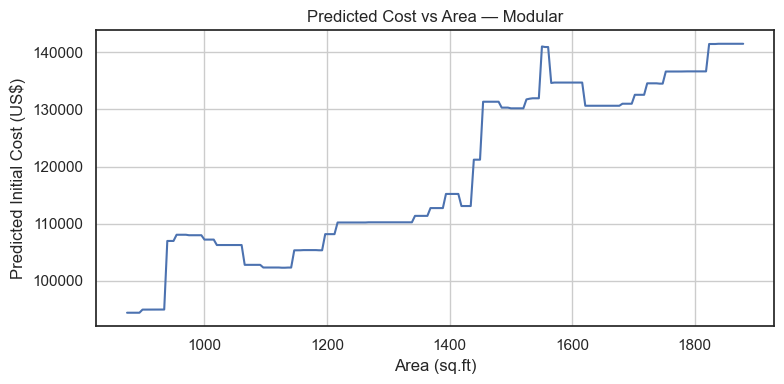

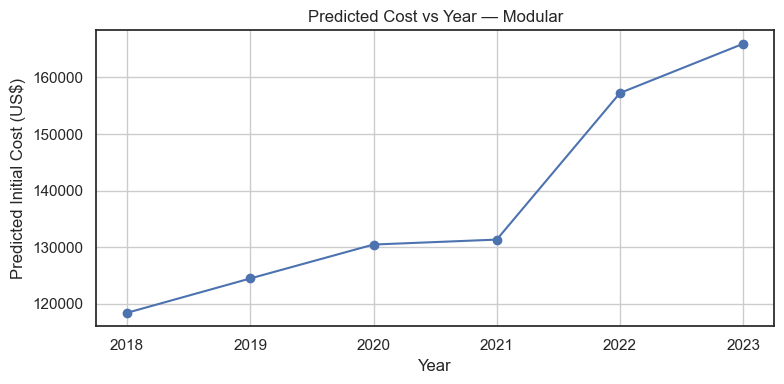

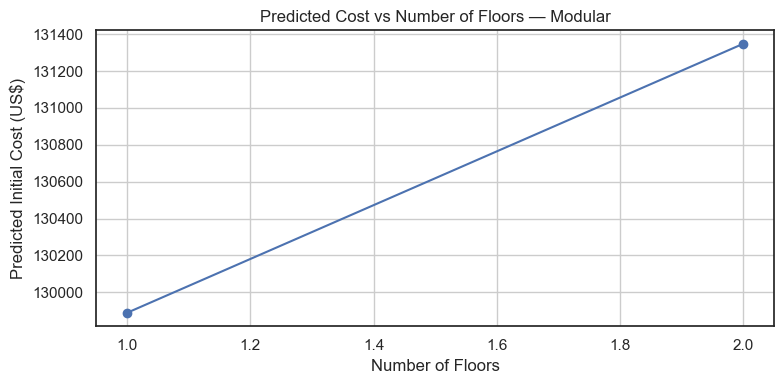

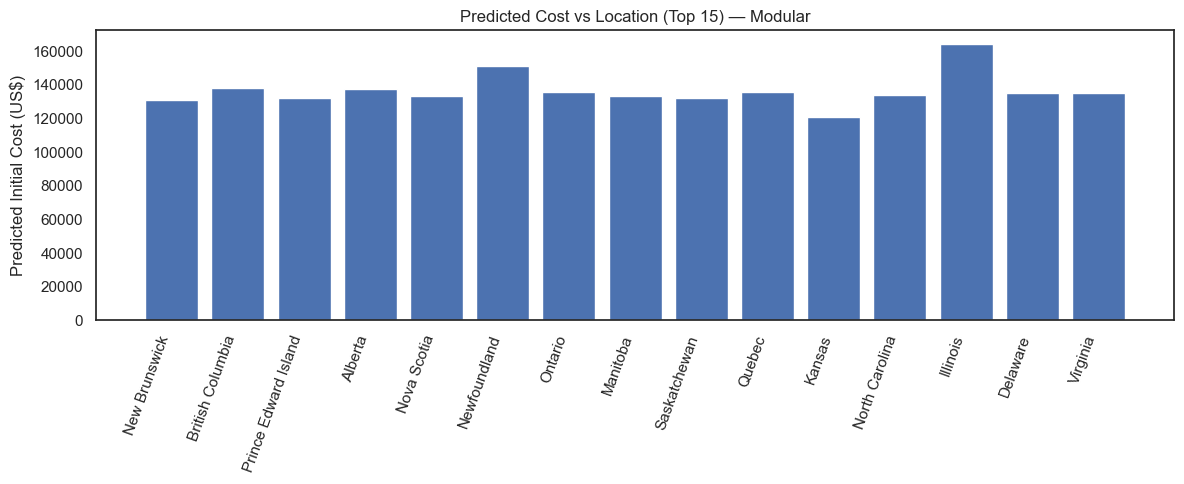

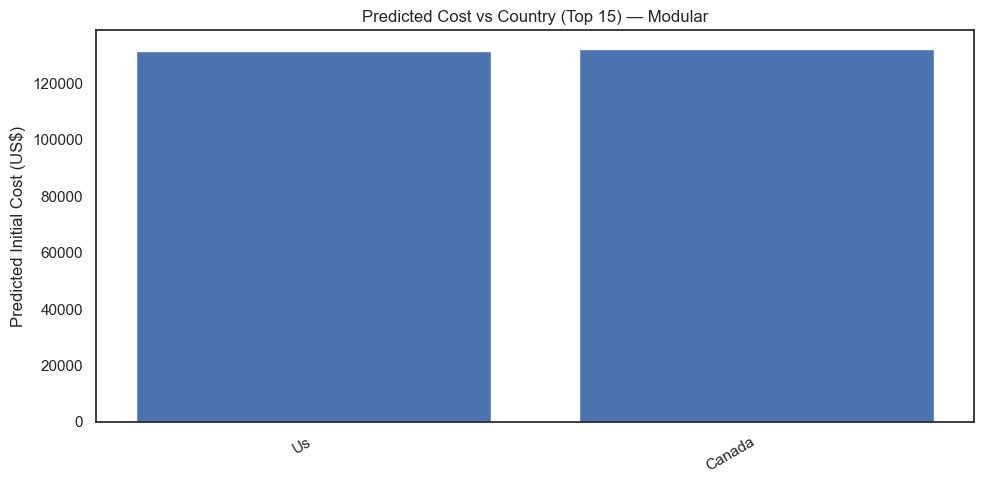

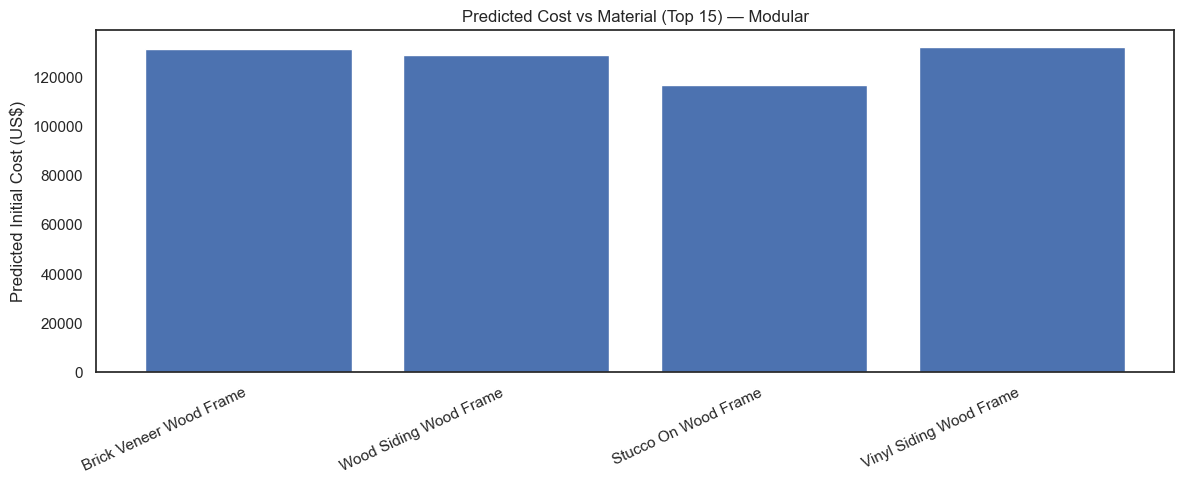

In [15]:
import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt

DATA  = "only_modular.csv"              # or "/mnt/data/all_modular_data.csv"
MODEL = "best_auto_model_allmodular.joblib"
TOP_K_CATS = 15

# -------------------------
# 1) Load data & model
# -------------------------
df = pd.read_csv(DATA)
df.columns = df.columns.str.strip()

# basic cleaning
for c in ["Location","Country","Material"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

for c in ["Area","Year","Number of Floors","Initial Cost"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# keep only rows with all needed features present
features = ["Area","Year","Location","Country","Number of Floors","Material"]
target   = "Initial Cost"
avail = [c for c in features + [target] if c in df.columns]
df = df.dropna(subset=avail).reset_index(drop=True)

model = joblib.load(MODEL)   # full Pipeline(preprocessor, estimator)

# -------------------------
# 2) Helpers (fixed values & probe builders)
# -------------------------
def typical_values(frame: pd.DataFrame) -> dict:
    """Return typical values (median/mode) for all features."""
    return {
        "Area": float(pd.to_numeric(frame["Area"], errors="coerce").median()),
        "Year": int(pd.to_numeric(frame["Year"], errors="coerce").median()),
        "Number of Floors": float(pd.to_numeric(frame["Number of Floors"], errors="coerce").median()),
        "Location": frame["Location"].mode().iat[0],
        "Country": frame["Country"].mode().iat[0],
        "Material": frame["Material"].mode().iat[0],
    }

FX = typical_values(df)

def base_probe(n: int) -> pd.DataFrame:
    """Build a baseline probe with typical FX repeated n times."""
    return pd.DataFrame({
        "Area":             [FX["Area"]]*n,
        "Year":             [FX["Year"]]*n,
        "Number of Floors": [FX["Number of Floors"]]*n,
        "Location":         [FX["Location"]]*n,
        "Country":          [FX["Country"]]*n,
        "Material":         [FX["Material"]]*n,
    })

def predict_over_numeric(var: str, grid) -> pd.DataFrame:
    probe = base_probe(len(grid))
    probe[var] = grid
    yhat = model.predict(probe)
    return pd.DataFrame({var: grid, "Predicted Cost": yhat})

def predict_over_categories(var: str, categories) -> pd.DataFrame:
    probe = base_probe(len(categories))
    probe[var] = categories
    yhat = model.predict(probe)
    return pd.DataFrame({var: categories, "Predicted Cost": yhat})

# -------------------------
# 3) Configure & plot
# -------------------------

# A) Predicted Cost vs Area (line over observed range)
area_min, area_max = df["Area"].min(), df["Area"].max()
area_grid = np.linspace(area_min, area_max, 200)
res_area = predict_over_numeric("Area", area_grid)
plt.figure(figsize=(8,4))
plt.plot(res_area["Area"], res_area["Predicted Cost"])
plt.title("Predicted Cost vs Area — Modular")
plt.xlabel("Area (sq.ft)"); plt.ylabel("Predicted Initial Cost (US$)")
plt.grid(True); plt.tight_layout(); 
plt.savefig("predicted_cost_vs_AREA.png", dpi=300)
plt.show()

# B) Predicted Cost vs Year (line over observed years)
years = sorted(df["Year"].dropna().astype(int).unique().tolist())
res_year = predict_over_numeric("Year", years)
plt.figure(figsize=(8,4))
plt.plot(res_year["Year"], res_year["Predicted Cost"], marker="o")
plt.title("Predicted Cost vs Year — Modular")
plt.xlabel("Year"); plt.ylabel("Predicted Initial Cost (US$)")
plt.grid(True); plt.xticks(years); plt.tight_layout(); 
plt.savefig("predicted_cost_vs_YEAR.png", dpi=300)
plt.show()

# C) Predicted Cost vs Number of Floors (line over observed floors)
floors = sorted(df["Number of Floors"].dropna().unique().tolist())
res_floors = predict_over_numeric("Number of Floors", floors)
plt.figure(figsize=(8,4))
plt.plot(res_floors["Number of Floors"], res_floors["Predicted Cost"], marker="o")
plt.title("Predicted Cost vs Number of Floors — Modular")
plt.xlabel("Number of Floors"); plt.ylabel("Predicted Initial Cost (US$)")
plt.grid(True); plt.tight_layout(); 
plt.savefig("predicted_cost_vs_FLOORS.png", dpi=300)
plt.show()

# D) Predicted Cost vs Location (bar — top K locations)
top_locations = df["Location"].value_counts().nlargest(TOP_K_CATS).index.tolist()
res_loc = predict_over_categories("Location", top_locations)
plt.figure(figsize=(12,5))
plt.bar(res_loc["Location"], res_loc["Predicted Cost"])
plt.title(f"Predicted Cost vs Location (Top {TOP_K_CATS}) — Modular")
plt.ylabel("Predicted Initial Cost (US$)")
plt.xticks(rotation=70, ha="right"); plt.tight_layout(); 
plt.savefig("predicted_cost_vs_LOCATION.png", dpi=300)
plt.show()

# E) Predicted Cost vs Country (bar — top K countries)
top_countries = df["Country"].value_counts().nlargest(TOP_K_CATS).index.tolist()
res_ctry = predict_over_categories("Country", top_countries)
plt.figure(figsize=(10,5))
plt.bar(res_ctry["Country"], res_ctry["Predicted Cost"])
plt.title(f"Predicted Cost vs Country (Top {TOP_K_CATS}) — Modular")
plt.ylabel("Predicted Initial Cost (US$)")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); 
plt.savefig("predicted_cost_vs_COUNTRY.png", dpi=300)
plt.show()

# F) Predicted Cost vs Material (bar — top K materials)
top_materials = df["Material"].value_counts().nlargest(TOP_K_CATS).index.tolist()
res_mat = predict_over_categories("Material", top_materials)
plt.figure(figsize=(12,5))
plt.bar(res_mat["Material"], res_mat["Predicted Cost"])
plt.title(f"Predicted Cost vs Material (Top {TOP_K_CATS}) — Modular")
plt.ylabel("Predicted Initial Cost (US$)")
plt.xticks(rotation=25, ha="right"); plt.tight_layout(); 
plt.savefig("predicted_cost_vs_MATERIAL.png", dpi=300)
plt.show()


***Predictions***

In [16]:
# === Batch predictions for the trained model from final_model_modular_data.ipynb ===
import os, json, joblib
import pandas as pd

# --- 1) Resolve the trained model path exactly like the notebook does ---
SPEC_CANDIDATES = [
    "auto_model_spec_allmodular.json",  # what the notebook writes
    "auto_model_spec.json",
]
def resolve_model_path():
    for sp in SPEC_CANDIDATES:
        if os.path.exists(sp):
            with open(sp, "r") as f:
                spec = json.load(f)
            mp = (spec.get("model_path")
                  or spec.get("MODEL_PATH")
                  or spec.get("model")
                  or spec.get("path"))
            if mp and os.path.exists(mp):
                return mp
            # if the spec stores just a filename, try next to the spec
            if mp:
                p2 = os.path.join(os.path.dirname(sp), mp)
                if os.path.exists(p2):
                    return p2
    # Fallback: if you know the exact filename, set it here
    fallback = "best_auto_model_allmodular.joblib"
    if os.path.exists(fallback):
        return fallback
    raise FileNotFoundError(
        "Could not locate the trained model. Make sure the notebook saved "
        "'auto_model_spec_allmodular.json' (with model_path) or place "
        "'best_auto_model_allmodular.joblib' in this folder."
    )

MODEL_PATH = resolve_model_path()
pipe = joblib.load(MODEL_PATH)  # sklearn Pipeline(preprocessor + estimator)

# --- 2) Main helper: pass scalars or lists; scalars broadcast automatically ---
def predict_cost_batch(
    areas,
    years,
    locations,
    countries,
    floors,
    materials,
    *, save_csv=True, csv_path="batch_predictions.csv"
):
    """
    Expects the exact feature names used by the trained model:
      - Area (float/int, SFT)
      - Year (int, e.g., 2023)
      - Location (string; match training spelling)
      - Country (string)
      - Number of Floors (float/int)
      - Material (string)

    You can pass scalars or lists for any argument.
    """
    def _to_list(x, n):
        return x if isinstance(x, (list, tuple, pd.Series)) else [x] * n

    # Determine N from the longest input
    objs = [areas, years, locations, countries, floors, materials]
    N = max(len(x) if isinstance(x, (list, tuple, pd.Series)) else 1 for x in objs)

    # Broadcast scalars
    areas     = _to_list(areas, N)
    years     = _to_list(years, N)
    locations = _to_list(locations, N)
    countries = _to_list(countries, N)
    floors    = _to_list(floors, N)
    materials = _to_list(materials, N)

    # Build the frame with exact column names from the notebook
    X = pd.DataFrame({
        "Area": areas,
        "Year": years,
        "Location": locations,
        "Country": countries,
        "Number of Floors": floors,
        "Material": materials,
    })

    # Light typo/normalization to match training (as in your notebook)
    X["Location"] = X["Location"].replace({
        "Massachussets": "Massachusetts",  # common fix you used before
        "Québec": "Quebec",               # guard against accent variants
        "Montréal": "Montreal",
    })
    X["Country"] = X["Country"].replace({
        "United States of America": "USA",
        "United States": "USA",
        "U.S.A.": "USA",
    })

    # Predict
    y_pred = pipe.predict(X)

    # Attach and (optionally) save
    out = X.copy()
    out["Predicted Initial Cost"] = y_pred
    if save_csv:
        out.to_csv(csv_path, index=False)
    return out

# --- 3) Example: edit any of these (scalars or lists) and re-run ---
areas      = 1800
years      = 2023
locations  = "Ontario"
countries  = "Canada"
floors     = 1.0
materials  = "Wood Siding Wood Frame"

pred_df = predict_cost_batch(
    areas, years, locations, countries, floors, materials,
    save_csv=True, csv_path="batch_predictions.csv"
)

# Pretty print
for i, row in pred_df.iterrows():
    print(f"Case {i+1}: Area={row['Area']} SFT -> Predicted Initial Cost (USD): {row['Predicted Initial Cost']:,.2f}")

print("\nSaved to: batch_predictions.csv")
print("Model loaded from:", MODEL_PATH)


Case 1: Area=1800 SFT -> Predicted Initial Cost (USD): 176,892.02

Saved to: batch_predictions.csv
Model loaded from: best_auto_model_allmodular.joblib


***Cost Prediction for Layout (Panelized Buildings with GA)***

In [20]:
# === Final cost adjustment layer: Functional Area + (Panelized | Volumetric), row-wise (corrected) ===
import os, json, joblib
import pandas as pd
from typing import Dict, Any, List

# --------------------------------------------------------------------
# 0) Load the trained pipeline (matches how your notebook writes the spec)
# --------------------------------------------------------------------
def _resolve_model_path():
    spec_candidates = ["auto_model_spec_allmodular.json", "auto_model_spec.json"]
    for sp in spec_candidates:
        if os.path.exists(sp):
            with open(sp, "r") as f:
                spec = json.load(f)
            mp = (spec.get("model_path")
                  or spec.get("MODEL_PATH")
                  or spec.get("model")
                  or spec.get("path"))
            if mp and os.path.exists(mp):
                return mp
            if mp:
                mp2 = os.path.join(os.path.dirname(sp), mp)
                if os.path.exists(mp2):
                    return mp2
    if os.path.exists("best_auto_model_allmodular.joblib"):
        return "best_auto_model_allmodular.joblib"
    raise FileNotFoundError(
        "Model not found. Ensure 'auto_model_spec_allmodular.json' (with model_path) exists "
        "or put 'best_auto_model_allmodular.joblib' next to this notebook."
    )

MODEL_PATH = _resolve_model_path()
PIPE = joblib.load(MODEL_PATH)  # sklearn Pipeline(preprocessor + estimator)

# --------------------------------------------------------------------
# 1) Predict base cost for any batch (same feature names as your notebook)
#    - Accepts scalars or lists; scalars broadcast
# --------------------------------------------------------------------
def predict_cost_batch(
    areas, years, locations, countries, floors, materials, *, csv_path=None
) -> pd.DataFrame:
    def _to_list(x, n): return x if isinstance(x, (list, tuple, pd.Series)) else [x]*n
    N = max(len(x) if isinstance(x, (list, tuple, pd.Series)) else 1
            for x in (areas, years, locations, countries, floors, materials))

    X = pd.DataFrame({
        "Area": _to_list(areas, N),
        "Year": _to_list(years, N),
        "Location": _to_list(locations, N),
        "Country": _to_list(countries, N),
        "Number of Floors": _to_list(floors, N),
        "Material": _to_list(materials, N),
    })

    # spelling guards to match training
    X["Location"] = X["Location"].replace({
        "Massachussets": "Massachusetts",
        "Québec": "Quebec",
        "Montréal": "Montreal",
    })
    X["Country"] = X["Country"].replace({
        "United States of America":"USA","United States":"USA","U.S.A.":"USA"
    })

    yhat = PIPE.predict(X)
    out = X.copy()
    out.insert(0, "Case", range(1, len(out)+1))
    out["Predicted Initial Cost"] = yhat
    if csv_path:
        out.to_csv(csv_path, index=False)
    return out

# --------------------------------------------------------------------
# 2) Functional-area multiplier: M_i = F(s_i) / F(s0)
#     s_k = a_k / A, F(s) = sum_k s_k * f_k
# --------------------------------------------------------------------
def functional_multiplier(
    gross_area: float,
    room_areas: Dict[str, float],
    rsmeans_factors_fk: Dict[str, float],
    baseline_shares_s0: Dict[str, float],
    eps: float = 1e-9
) -> float:
    if gross_area <= 0:
        return 1.0
    s_i = {k: max(a_k, 0.0) / gross_area for k, a_k in room_areas.items()}

    F_si = sum(s_i.get(k, 0.0) * rsmeans_factors_fk.get(k, 0.0) for k in set(s_i) | set(rsmeans_factors_fk))
    F_s0 = sum(baseline_shares_s0.get(k, 0.0) * rsmeans_factors_fk.get(k, 0.0) for k in set(baseline_shares_s0) | set(rsmeans_factors_fk))

    if F_s0 <= eps:
        return 1.0
    return float(F_si / F_s0)

# --------------------------------------------------------------------
# 3) Centering helper for any raw factor C ∈ [Cmin, Cmax] -> multiplicative around 1.0
#     r = (C - C_min) / (C_max - C_min); F = 1 + delta*(2*r - 1)
# --------------------------------------------------------------------
def centered_factor(C: float, C_min: float, C_max: float, delta: float = 0.15) -> float:
    if C_max <= C_min:
        return 1.0
    r = (C - C_min) / (C_max - C_min)
    return 1.0 + delta * (2.0 * r - 1.0)

# --------------------------------------------------------------------
# 4) Build per-factor centering bounds (Cmin,Cmax) from your actual layouts
#     C_raw = 1 + w*(u/Umax) computed across rows (per factor) -> min/max set from data
# --------------------------------------------------------------------
def build_centering_from_layouts(layout_vars_df: pd.DataFrame,
                                 cfg_base: Dict[str, Dict[str, float]]) -> Dict[str, Dict[str, float]]:
    """
    cfg_base[name] must include: {"col": <u-column>, "w": float, "Umax": float, "alpha": float}
    Returns cfg with added "Cmin","Cmax" computed from C_raw across rows.
    If a u-column is missing or Umax<=0 or w==0, the factor is neutralized (alpha=0).
    """
    cfg = {}
    for name, d in cfg_base.items():
        col   = d.get("col")
        w     = float(d.get("w", 0.0))
        Umax  = float(d.get("Umax", 1.0))
        alpha = float(d.get("alpha", 0.0))

        if not col or col not in layout_vars_df.columns or Umax <= 0 or w == 0:
            cfg[name] = {**d, "Cmin": 1.0, "Cmax": 1.0, "alpha": 0.0}
            continue

        u_vals = layout_vars_df[col].fillna(0).astype(float).values
        C_raw  = 1.0 + w * (u_vals / Umax)
        Cmin, Cmax = float(C_raw.min()), float(C_raw.max())
        if Cmax <= Cmin:
            Cmin, Cmax, alpha = 1.0, 1.0, 0.0

        cfg[name] = {**d, "Cmin": Cmin, "Cmax": Cmax, "alpha": alpha}
    return cfg

def normalize_alphas(cfg: Dict[str, Dict[str, float]]) -> Dict[str, Dict[str, float]]:
    s = sum(float(d.get("alpha", 0.0)) for d in cfg.values())
    if s <= 0:
        return cfg
    return {k: {**d, "alpha": float(d.get("alpha", 0.0))/s} for k, d in cfg.items()}

# --------------------------------------------------------------------
# 5) Row-wise multipliers (per-layout)
# --------------------------------------------------------------------
def panelized_multiplier_row(row, cfg: Dict[str, Dict[str, float]], delta: float = 0.15) -> float:
    prod = 1.0
    for _, d in cfg.items():
        u     = float(row.get(d.get("col", ""), 0.0) or 0.0)
        w     = float(d.get("w", 0.0))
        Umax  = float(d.get("Umax", 1.0))
        Cmin  = float(d.get("Cmin", 1.0))
        Cmax  = float(d.get("Cmax", 1.0))
        alpha = float(d.get("alpha", 0.0))
        if Umax <= 0 or w == 0 or Cmax <= Cmin or alpha == 0.0:
            continue
        C_raw = 1.0 + w * (u / Umax)
        F     = centered_factor(C_raw, Cmin, Cmax, delta=delta)
        prod *= (F ** alpha)
    return float(prod)

def volumetric_multiplier_row(row, cfg: Dict[str, Dict[str, float]], delta: float = 0.15) -> float:
    prod = 1.0
    for _, d in cfg.items():
        u     = float(row.get(d.get("col", ""), 0.0) or 0.0)
        w     = float(d.get("w", 0.0))
        Umax  = float(d.get("Umax", 1.0))
        Cmin  = float(d.get("Cmin", 1.0))
        Cmax  = float(d.get("Cmax", 1.0))
        alpha = float(d.get("alpha", 0.0))
        if Umax <= 0 or w == 0 or Cmax <= Cmin or alpha == 0.0:
            continue
        C_raw = 1.0 + w * (u / Umax)
        F     = centered_factor(C_raw, Cmin, Cmax, delta=delta)
        prod *= (F ** alpha)
    return float(prod)

# --------------------------------------------------------------------
# 6) Compose final costs per row
# --------------------------------------------------------------------
def compute_final_costs(
    pred_df: pd.DataFrame,
    layout_vars_df: pd.DataFrame,
    *,
    rsmeans_factors_fk: Dict[str, float],
    baseline_shares_s0: Dict[str, float],
    building_type: str,                              # "panelized" | "volumetric"
    panelized_cfg: Dict[str, Dict[str, float]] = None,
    volumetric_cfg: Dict[str, Dict[str, float]] = None,
    delta_center: float = 0.15
) -> pd.DataFrame:
    assert building_type in {"panelized", "volumetric"}

    if "Case" not in pred_df.columns:
        pred_df = pred_df.reset_index().rename(columns={"index":"Case"})
        pred_df["Case"] = pred_df["Case"] + 1

    df = pred_df.merge(layout_vars_df, on="Case", how="left")

    final_costs, func_mults, sys_mults = [], [], []
    room_cols = [c for c in df.columns if c.startswith("Room:")]

    for _, r in df.iterrows():
        base  = float(r["Predicted Initial Cost"])
        gross = float(r.get("GrossArea", r.get("Area", 0.0)))

        # Functional multiplier (uses room shares)
        room_areas = {c.split("Room:",1)[1].strip(): float(r[c]) if pd.notnull(r[c]) else 0.0
                      for c in room_cols}
        M_func = functional_multiplier(
            gross_area=gross,
            room_areas=room_areas,
            rsmeans_factors_fk=rsmeans_factors_fk,
            baseline_shares_s0=baseline_shares_s0
        )

        # System multiplier (row-wise per building type)
        if building_type == "panelized":
            M_sys = panelized_multiplier_row(r, panelized_cfg or {}, delta=delta_center)
        else:
            M_sys = volumetric_multiplier_row(r, volumetric_cfg or {}, delta=delta_center)

        final_costs.append(base * M_func * M_sys)
        func_mults.append(M_func)
        sys_mults.append(M_sys)

    out = df.copy()
    out["Functional Multiplier"] = func_mults
    out["System Multiplier"]     = sys_mults
    out["Final Adjusted Cost"]   = final_costs
    return out



# b) Per-layout variables: GrossArea, room areas, and per-layout u_* metrics
layout_vars_df = pd.DataFrame({
    "Case": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30,31, 32, 33, 34, 35, 36, 37, 38, 39, 40],
    "GrossArea": [635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 635.50, 651.00, 651.00, 651.00, 651.00, 620.00, 620.00],

    # Room areas (prefix "Room:" so the code auto-detects)
    "Room:Bedroom":  [232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 232.5, 248.00, 248.00, 217, 232.5],
    "Room:Kitchen":  [62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62],
    "Room:Bathroom": [62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 46.50],
    "Room:Dining":   [139.5, 139.50, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5],
    "Room:Living":   [139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 139.5, 155.00, 155.0, 139.5, 139.5, 139.5, 139.5],

    # ---- Panelized metrics (per-layout u-values) ----
    "u_CTP":  [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 3, 3],      # unique panel types
    "u_CIP":  [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 7, 7],      # internal panels
    "u_CEP":  [19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20, 19, 19],     # external panels
    "u_CPL":  [259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 259.77, 185, 185, 185, 185, 208.6, 208.6],    # total panel length
    "u_CRPJ": [10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 9, 9, 9, 9, 11, 11],     # regular joints (2 panels)
    "u_CCPJ": [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 8, 8, 8, 8, 6, 6],      # complex joints (>2)

})
# --------------------------------------------------------------------
# 7) EXAMPLE — 3 layouts (edit with your real values/columns)
# --------------------------------------------------------------------
# a) Base predictions (or reuse your existing pred_df)
pred_df = predict_cost_batch(
    areas=layout_vars_df["GrossArea"].tolist(),
    years=2023,
    locations="Ontario",
    countries="Canada",
    floors=1.0,
    materials="Wood Siding Wood Frame"
)

# c) RSMeans factors & baseline room shares (replace with your calibrated numbers)
rsmeans_factors_fk = {
    "Bedroom": 0.46, "Kitchen": 0.77, "Bathroom": 1.62, "Dining": 0.52, "Living": 1.18
}
baseline_shares_s0 = {
    "Bedroom": 0.39, "Kitchen": 0.10, "Bathroom": 0.09, "Dining": 0.16, "Living": 0.26
}

# d) Define BASE configs (without Cmin/Cmax); alphas will be normalized
panelized_cfg_base = {
    "CTP":  {"col": "u_CTP",  "w": 1.0, "Umax": 4,   "alpha": 0.20},
    "CIP":  {"col": "u_CIP",  "w": 1.0, "Umax": 7,   "alpha": 0.15},
    "CEP":  {"col": "u_CEP",  "w": 1.0, "Umax": 20,  "alpha": 0.15},
    "CPL":  {"col": "u_CPL",  "w": 1.0, "Umax": 259.77, "alpha": 0.20},
    "CRPJ": {"col": "u_CRPJ", "w": 1.0, "Umax": 11,  "alpha": 0.15},
    "CCPJ": {"col": "u_CCPJ", "w": 1.0, "Umax": 8,   "alpha": 0.15},
}


# e) Build data-driven centering and normalize alphas
panelized_cfg  = normalize_alphas(build_centering_from_layouts(layout_vars_df, panelized_cfg_base))


# f) Choose system and compute final costs
building_type = "panelized"  # or "volumetric"

final_df = compute_final_costs(
    pred_df,
    layout_vars_df,
    rsmeans_factors_fk=rsmeans_factors_fk,
    baseline_shares_s0=baseline_shares_s0,
    building_type=building_type,
    panelized_cfg=panelized_cfg,
    delta_center=0.15
)

# Inspect:
# final_df[["Case","Functional Multiplier","System Multiplier","Final Adjusted Cost"]]
final_df.head()

output_path = "final_cost_results_ga.xlsx"

final_df.to_excel(
    output_path,
    index=False,
    sheet_name="Final_Adjusted_Costs"
)

print(f"Full results saved to: {output_path}")

print(final_df.head())

Full results saved to: final_cost_results_ga.xlsx
   Case   Area  Year Location Country  Number of Floors  \
0     1  635.5  2023  Ontario  Canada               1.0   
1     2  635.5  2023  Ontario  Canada               1.0   
2     3  635.5  2023  Ontario  Canada               1.0   
3     4  635.5  2023  Ontario  Canada               1.0   
4     5  635.5  2023  Ontario  Canada               1.0   

                 Material  Predicted Initial Cost  GrossArea  Room:Bedroom  \
0  Wood Siding Wood Frame               136404.02      635.5         232.5   
1  Wood Siding Wood Frame               136404.02      635.5         232.5   
2  Wood Siding Wood Frame               136404.02      635.5         232.5   
3  Wood Siding Wood Frame               136404.02      635.5         232.5   
4  Wood Siding Wood Frame               136404.02      635.5         232.5   

   ...  Room:Living  u_CTP  u_CIP  u_CEP   u_CPL  u_CRPJ  u_CCPJ  \
0  ...        139.5      2      5     19  259.77      10  

***Cost Prediction for Layout (Panlized Building - Ant Colony)***

***Cost Prediction for Layout (Volumetric Building)***

In [16]:
# === Final cost adjustment layer: Functional Area + (Panelized | Volumetric), row-wise (corrected) ===
import os, json, joblib
import pandas as pd
from typing import Dict, Any, List

# --------------------------------------------------------------------
# 0) Load the trained pipeline (matches how your notebook writes the spec)
# --------------------------------------------------------------------
def _resolve_model_path():
    spec_candidates = ["auto_model_spec_allmodular.json", "auto_model_spec.json"]
    for sp in spec_candidates:
        if os.path.exists(sp):
            with open(sp, "r") as f:
                spec = json.load(f)
            mp = (spec.get("model_path")
                  or spec.get("MODEL_PATH")
                  or spec.get("model")
                  or spec.get("path"))
            if mp and os.path.exists(mp):
                return mp
            if mp:
                mp2 = os.path.join(os.path.dirname(sp), mp)
                if os.path.exists(mp2):
                    return mp2
    if os.path.exists("best_auto_model_allmodular.joblib"):
        return "best_auto_model_allmodular.joblib"
    raise FileNotFoundError(
        "Model not found. Ensure 'auto_model_spec_allmodular.json' (with model_path) exists "
        "or put 'best_auto_model_allmodular.joblib' next to this notebook."
    )

MODEL_PATH = _resolve_model_path()
PIPE = joblib.load(MODEL_PATH)  # sklearn Pipeline(preprocessor + estimator)

# --------------------------------------------------------------------
# 1) Predict base cost for any batch (same feature names as your notebook)
#    - Accepts scalars or lists; scalars broadcast
# --------------------------------------------------------------------
def predict_cost_batch(
    areas, years, locations, countries, floors, materials, *, csv_path=None
) -> pd.DataFrame:
    def _to_list(x, n): return x if isinstance(x, (list, tuple, pd.Series)) else [x]*n
    N = max(len(x) if isinstance(x, (list, tuple, pd.Series)) else 1
            for x in (areas, years, locations, countries, floors, materials))

    X = pd.DataFrame({
        "Area": _to_list(areas, N),
        "Year": _to_list(years, N),
        "Location": _to_list(locations, N),
        "Country": _to_list(countries, N),
        "Number of Floors": _to_list(floors, N),
        "Material": _to_list(materials, N),
    })

    # spelling guards to match training
    X["Location"] = X["Location"].replace({
        "Massachussets": "Massachusetts",
        "Québec": "Quebec",
        "Montréal": "Montreal",
    })
    X["Country"] = X["Country"].replace({
        "United States of America":"USA","United States":"USA","U.S.A.":"USA"
    })

    yhat = PIPE.predict(X)
    out = X.copy()
    out.insert(0, "Case", range(1, len(out)+1))
    out["Predicted Initial Cost"] = yhat
    if csv_path:
        out.to_csv(csv_path, index=False)
    return out

# --------------------------------------------------------------------
# 2) Functional-area multiplier: M_i = F(s_i) / F(s0)
#     s_k = a_k / A, F(s) = sum_k s_k * f_k
# --------------------------------------------------------------------
def functional_multiplier(
    gross_area: float,
    room_areas: Dict[str, float],
    rsmeans_factors_fk: Dict[str, float],
    baseline_shares_s0: Dict[str, float],
    eps: float = 1e-9
) -> float:
    if gross_area <= 0:
        return 1.0
    s_i = {k: max(a_k, 0.0) / gross_area for k, a_k in room_areas.items()}

    F_si = sum(s_i.get(k, 0.0) * rsmeans_factors_fk.get(k, 0.0) for k in set(s_i) | set(rsmeans_factors_fk))
    F_s0 = sum(baseline_shares_s0.get(k, 0.0) * rsmeans_factors_fk.get(k, 0.0) for k in set(baseline_shares_s0) | set(rsmeans_factors_fk))

    if F_s0 <= eps:
        return 1.0
    return float(F_si / F_s0)

# --------------------------------------------------------------------
# 3) Centering helper for any raw factor C ∈ [Cmin, Cmax] -> multiplicative around 1.0
#     r = (C - C_min) / (C_max - C_min); F = 1 + delta*(2*r - 1)
# --------------------------------------------------------------------
def centered_factor(C: float, C_min: float, C_max: float, delta: float = 0.15) -> float:
    if C_max <= C_min:
        return 1.0
    r = (C - C_min) / (C_max - C_min)
    return 1.0 + delta * (2.0 * r - 1.0)

# --------------------------------------------------------------------
# 4) Build per-factor centering bounds (Cmin,Cmax) from your actual layouts
#     C_raw = 1 + w*(u/Umax) computed across rows (per factor) -> min/max set from data
# --------------------------------------------------------------------
def build_centering_from_layouts(layout_vars_df: pd.DataFrame,
                                 cfg_base: Dict[str, Dict[str, float]]) -> Dict[str, Dict[str, float]]:
    """
    cfg_base[name] must include: {"col": <u-column>, "w": float, "Umax": float, "alpha": float}
    Returns cfg with added "Cmin","Cmax" computed from C_raw across rows.
    If a u-column is missing or Umax<=0 or w==0, the factor is neutralized (alpha=0).
    """
    cfg = {}
    for name, d in cfg_base.items():
        col   = d.get("col")
        w     = float(d.get("w", 0.0))
        Umax  = float(d.get("Umax", 1.0))
        alpha = float(d.get("alpha", 0.0))

        if not col or col not in layout_vars_df.columns or Umax <= 0 or w == 0:
            cfg[name] = {**d, "Cmin": 1.0, "Cmax": 1.0, "alpha": 0.0}
            continue

        u_vals = layout_vars_df[col].fillna(0).astype(float).values
        C_raw  = 1.0 + w * (u_vals / Umax)
        Cmin, Cmax = float(C_raw.min()), float(C_raw.max())
        if Cmax <= Cmin:
            Cmin, Cmax, alpha = 1.0, 1.0, 0.0

        cfg[name] = {**d, "Cmin": Cmin, "Cmax": Cmax, "alpha": alpha}
    return cfg

def normalize_alphas(cfg: Dict[str, Dict[str, float]]) -> Dict[str, Dict[str, float]]:
    s = sum(float(d.get("alpha", 0.0)) for d in cfg.values())
    if s <= 0:
        return cfg
    return {k: {**d, "alpha": float(d.get("alpha", 0.0))/s} for k, d in cfg.items()}

# --------------------------------------------------------------------
# 5) Row-wise multipliers (per-layout)
# --------------------------------------------------------------------
def panelized_multiplier_row(row, cfg: Dict[str, Dict[str, float]], delta: float = 0.15) -> float:
    prod = 1.0
    for _, d in cfg.items():
        u     = float(row.get(d.get("col", ""), 0.0) or 0.0)
        w     = float(d.get("w", 0.0))
        Umax  = float(d.get("Umax", 1.0))
        Cmin  = float(d.get("Cmin", 1.0))
        Cmax  = float(d.get("Cmax", 1.0))
        alpha = float(d.get("alpha", 0.0))
        if Umax <= 0 or w == 0 or Cmax <= Cmin or alpha == 0.0:
            continue
        C_raw = 1.0 + w * (u / Umax)
        F     = centered_factor(C_raw, Cmin, Cmax, delta=delta)
        prod *= (F ** alpha)
    return float(prod)

def volumetric_multiplier_row(row, cfg: Dict[str, Dict[str, float]], delta: float = 0.15) -> float:
    prod = 1.0
    for _, d in cfg.items():
        u     = float(row.get(d.get("col", ""), 0.0) or 0.0)
        w     = float(d.get("w", 0.0))
        Umax  = float(d.get("Umax", 1.0))
        Cmin  = float(d.get("Cmin", 1.0))
        Cmax  = float(d.get("Cmax", 1.0))
        alpha = float(d.get("alpha", 0.0))
        if Umax <= 0 or w == 0 or Cmax <= Cmin or alpha == 0.0:
            continue
        C_raw = 1.0 + w * (u / Umax)
        F     = centered_factor(C_raw, Cmin, Cmax, delta=delta)
        prod *= (F ** alpha)
    return float(prod)

# --------------------------------------------------------------------
# 6) Compose final costs per row
# --------------------------------------------------------------------
def compute_final_costs(
    pred_df: pd.DataFrame,
    layout_vars_df: pd.DataFrame,
    *,
    rsmeans_factors_fk: Dict[str, float],
    baseline_shares_s0: Dict[str, float],
    building_type: str,                              # "panelized" | "volumetric"
    panelized_cfg: Dict[str, Dict[str, float]] = None,
    volumetric_cfg: Dict[str, Dict[str, float]] = None,
    delta_center: float = 0.15
) -> pd.DataFrame:
    assert building_type in {"panelized", "volumetric"}

    if "Case" not in pred_df.columns:
        pred_df = pred_df.reset_index().rename(columns={"index":"Case"})
        pred_df["Case"] = pred_df["Case"] + 1

    df = pred_df.merge(layout_vars_df, on="Case", how="left")

    final_costs, func_mults, sys_mults = [], [], []
    room_cols = [c for c in df.columns if c.startswith("Room:")]

    for _, r in df.iterrows():
        base  = float(r["Predicted Initial Cost"])
        gross = float(r.get("GrossArea", r.get("Area", 0.0)))

        # Functional multiplier (uses room shares)
        room_areas = {c.split("Room:",1)[1].strip(): float(r[c]) if pd.notnull(r[c]) else 0.0
                      for c in room_cols}
        M_func = functional_multiplier(
            gross_area=gross,
            room_areas=room_areas,
            rsmeans_factors_fk=rsmeans_factors_fk,
            baseline_shares_s0=baseline_shares_s0
        )

        # System multiplier (row-wise per building type)
        if building_type == "panelized":
            M_sys = panelized_multiplier_row(r, panelized_cfg or {}, delta=delta_center)
        else:
            M_sys = volumetric_multiplier_row(r, volumetric_cfg or {}, delta=delta_center)

        final_costs.append(base * M_func * M_sys)
        func_mults.append(M_func)
        sys_mults.append(M_sys)

    out = df.copy()
    out["Functional Multiplier"] = func_mults
    out["System Multiplier"]     = sys_mults
    out["Final Adjusted Cost"]   = final_costs
    return out

# --------------------------------------------------------------------
# 7) EXAMPLE — 3 layouts (edit with your real values/columns)
# --------------------------------------------------------------------
# a) Base predictions (or reuse your existing pred_df)
pred_df = predict_cost_batch(
    areas=[1800, 1800, 1800],
    years=2023,
    locations="Ontario",
    countries="Canada",
    floors=1.0,
    materials="Wood Siding Wood Frame"
)

# b) Per-layout variables: GrossArea, room areas, and per-layout u_* metrics
layout_vars_df = pd.DataFrame({
    "Case": [1, 2, 3],
    "GrossArea": [1800, 1800, 1800],

    # Room areas (prefix "Room:" so the code auto-detects)
    "Room:Bedroom":  [702, 702, 702],
    "Room:Kitchen":  [180,  180, 180],
    "Room:Bathroom": [162,  162,  162],
    "Room:Dining":   [288, 288, 288],
    "Room:Living":   [468, 468, 468],

    # ---- Panelized metrics (per-layout u-values) ----
    "u_CTP":  [5,   6,   6],      # unique panel types
    "u_CIP":  [6,   8,   5],      # internal panels
    "u_CEP":  [11,  14,  16],     # external panels
    "u_CPL":  [190, 206, 196],    # total panel length
    "u_CRPJ": [22,  27,  25],     # regular joints (2 panels)
    "u_CCPJ": [4,   7,   6],      # complex joints (>2)

    # ---- Volumetric metrics (per-layout u-values) ----
    "u_CTM":  [1,  2,  2],        # unique module types
    "u_CHMJ": [6,  6,  8],        # horizontal module joints
    "u_CCMJ": [8,  4, 16],        # corner joints
    "u_CIMJ": [0,  0,  0],        # internal module joints
    "u_CIPM": [10, 10, 10],       # internal panels in modules
    "u_CEPM": [6,  6,  8],        # external panels in modules
    "u_CMWM": [2,  2,  8],        # mate walls
})

# c) RSMeans factors & baseline room shares (replace with your calibrated numbers)
rsmeans_factors_fk = {
    "Bedroom": 0.46, "Kitchen": 0.77, "Bathroom": 1.62, "Dining": 0.52, "Living": 1.18
}
baseline_shares_s0 = {
    "Bedroom": 0.39, "Kitchen": 0.10, "Bathroom": 0.09, "Dining": 0.16, "Living": 0.26
}

# d) Define BASE configs (without Cmin/Cmax); alphas will be normalized
panelized_cfg_base = {
    "CTP":  {"col": "u_CTP",  "w": 1.0, "Umax": 6,   "alpha": 0.20},
    "CIP":  {"col": "u_CIP",  "w": 1.0, "Umax": 8,   "alpha": 0.15},
    "CEP":  {"col": "u_CEP",  "w": 1.0, "Umax": 16,  "alpha": 0.15},
    "CPL":  {"col": "u_CPL",  "w": 1.0, "Umax": 206, "alpha": 0.20},
    "CRPJ": {"col": "u_CRPJ", "w": 1.0, "Umax": 27,  "alpha": 0.15},
    "CCPJ": {"col": "u_CCPJ", "w": 1.0, "Umax": 7,   "alpha": 0.15},
}
volumetric_cfg_base = {
    "CTM":  {"col": "u_CTM",  "w": 1.0, "Umax": 2,   "alpha": 0.20},
    "CHMJ": {"col": "u_CHMJ", "w": 1.0, "Umax": 8,   "alpha": 0.15},
    "CCMJ": {"col": "u_CCMJ", "w": 1.0, "Umax": 16,  "alpha": 0.15},
    "CIMJ": {"col": "u_CIMJ", "w": 1.0, "Umax": 1,   "alpha": 0.10},  # avoid 0; or drop if always 0
    "CIPM": {"col": "u_CIPM", "w": 1.0, "Umax": 16,  "alpha": 0.15},
    "CEPM": {"col": "u_CEPM", "w": 1.0, "Umax": 8,   "alpha": 0.15},
    "CMWM": {"col": "u_CMWM", "w": 1.0, "Umax": 8,   "alpha": 0.10},
}

# e) Build data-driven centering and normalize alphas
panelized_cfg  = normalize_alphas(build_centering_from_layouts(layout_vars_df, panelized_cfg_base))
volumetric_cfg = normalize_alphas(build_centering_from_layouts(layout_vars_df, volumetric_cfg_base))

# f) Choose system and compute final costs
building_type = "volumetric"

final_df = compute_final_costs(
    pred_df,
    layout_vars_df,
    rsmeans_factors_fk=rsmeans_factors_fk,
    baseline_shares_s0=baseline_shares_s0,
    building_type=building_type,
    panelized_cfg=panelized_cfg,
    volumetric_cfg=volumetric_cfg,
    delta_center=0.15
)

# Inspect:
# final_df[["Case","Functional Multiplier","System Multiplier","Final Adjusted Cost"]]
final_df.head()


,Case,Area,Year,Location,Country,Number of Floors,Material,Predicted Initial Cost,GrossArea,Room:Bedroom,...,u_CTM,u_CHMJ,u_CCMJ,u_CIMJ,u_CIPM,u_CEPM,u_CMWM,Functional Multiplier,System Multiplier,Final Adjusted Cost
0,1,1800,2023,Ontario,Canada,1.0,Wood Siding Wood Frame,176892.023667,1800,702,...,1,6,8,0,10,6,2,1.0,0.869120,153740.437275
1,2,1800,2023,Ontario,Canada,1.0,Wood Siding Wood Frame,176892.023667,1800,702,...,2,6,4,0,10,6,2,1.0,0.921354,162980.215094
2,3,1800,2023,Ontario,Canada,1.0,Wood Siding Wood Frame,176892.023667,1800,702,...,2,8,16,0,10,8,8,1.0,1.150000,203425.827217
